# Previsão de Resultado de Partidas de League of Legends

## Projeto Final — Módulo 43 | Case 03 — Riot Games

---

### 🎯 Objetivo do Projeto
Desenvolver um **modelo de Machine Learning** capaz de prever o **time vencedor** de uma partida de League of Legends com base em dados coletados durante os primeiros minutos de jogo (estado pós-início de partida).
 
### 📋 Escopo Técnico
| Item | Detalhe |
|------|---------|
| **Problema** | Classificação binária — Time Azul vence (1) ou perde (0) |
| **Dados** | ~9.879 partidas ranqueadas com 40 variáveis |
| **Modelos** | Regressão Logística, Naive Bayes, Árvore de Decisão, Random Forest, Gradient Boosting |
| **Métrica principal** | AUC-ROC (solicitado pelo stakeholder) |
| **Bônus** | Cross-validation, Ensemble, GridSearchCV, App Streamlit |
 
### ✍️ Índice
1. Setup e Importações
2. Carregamento e Entendimento dos Dados
3. Análise Exploratória de Dados (EDA)
4. Preparação dos Dados e Feature Engineering
5. Modelagem
6. Avaliação Comparativa
7. Ajuste de Hiperparâmetros (Tuning)
8. Insights, Conclusões e Recomendações

# 1. Setup e Importações

In [845]:
# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Scikit-learn: pré-processamento
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler

# Scikit-learn: modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-learn: métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# Persistência de modelos
import joblib
import os

In [846]:
# Configurações globais de visualização
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f9fa",
        "axes.grid": True,
        "grid.alpha": 0.35,
        "grid.linewidth": 0.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": "DejaVu Sans",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 11,
    }
)
sns.set_palette("deep")

In [847]:
# Constantes do projeto
BLUE = "#1f77b4"  # Time Azul — vitória
RED = "#d62728"  # Time Vermelho — derrota
GREEN = "#2ca02c"  # Métricas positivas
AMBER = "#ff7f0e"  # Destaques / atenção
PURPLE = "#9467bd"  # Ensemble
RANDOM_STATE = 42

In [848]:
# Pastas de saída
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)

# 2. Carregamento e Entendimento dos Dados
 
### 📖 Dicionário de Variáveis (40 colunas)
 
O dataset registra o estado da partida em um ponto pós-início de jogo (~10 min). Toda variável com prefixo **`blue`** tem uma equivalente em **`red`**, exceto a target. Total: 1 identificador + 1 target + 19 features × 2 times = 40 colunas.
 
| Variável (prefixo `blue`/`red`) | Tipo | Descrição |
|----------------------------------|------|-----------|
| `gameId` | int | Identificador único da partida *(coluna única, sem prefixo)* |
| `blueWins` | int (0/1) | **TARGET** — 1 se o Time Azul venceu *(coluna única, sem equivalente red)* |
| `WardsPlaced` | int | Wards colocadas (visão no mapa) |
| `WardsDestroyed` | int | Wards inimigas destruídas |
| `FirstBlood` | int (0/1) | Se o time obteve o primeiro abate da partida |
| `Kills` | int | Total de campeões abatidos |
| `Deaths` | int | Total de mortes do time (= Kills do time adversário) |
| `Assists` | int | Total de assistências em abates |
| `EliteMonsters` | int | Monstros elite capturados (Dragões + Arautos somados) |
| `Dragons` | int | Dragões capturados |
| `Heralds` | int | Arautos (Heralds) capturados |
| `TowersDestroyed` | int | Torres inimigas destruídas |
| `TotalGold` | int | Ouro total acumulado pelo time |
| `AvgLevel` | float | Nível médio dos campeões do time |
| `TotalExperience` | int | Experiência total acumulada pelo time |
| `TotalMinionsKilled` | int | Total de minions (creeps de lane) abatidos — *farm* |
| `TotalJungleMinionsKilled` | int | Total de monstros de selva abatidos — *farm de jungle* |
| `GoldDiff` | int | Diferença de ouro em relação ao time adversário (blue − red) |
| `ExperienceDiff` | int | Diferença de experiência em relação ao adversário (blue − red) |
| `CSPerMin` | float | CS (minions + jungle) por minuto — eficiência de farm |
| `GoldPerMin` | float | Ouro ganho por minuto |
 
> ⚠️ Note que `redGoldDiff` = −`blueGoldDiff` e `redExperienceDiff` = −`blueExperienceDiff` (espelhos exatos), e `blueDeaths` = `redKills` enquanto `redDeaths` = `blueKills`. Essas redundâncias serão tratadas na seção de Preparação dos Dados.

In [849]:
# carregar o dataset
DATASET_PATH = "data/raw/Base_M43_Pratique_LOL_RANKED_WIN.csv"
df = pd.read_csv(DATASET_PATH)
df

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9874,4527873286,1,17,2,1,7,4,5,1,1,...,0,15246,6.8,16498,229,34,-2519,-2469,22.9,1524.6
9875,4527797466,1,54,0,0,6,4,8,1,1,...,0,15456,7.0,18367,206,56,-782,-888,20.6,1545.6
9876,4527713716,0,23,1,0,6,7,5,0,0,...,0,18319,7.4,19909,261,60,2416,1877,26.1,1831.9
9877,4527628313,0,14,4,1,2,3,3,1,1,...,0,15298,7.2,18314,247,40,839,1085,24.7,1529.8


In [850]:
# Tipos de dados
print(df.dtypes.value_counts().to_string())
df.dtypes

int64      34
float64     6


gameId                            int64
blueWins                          int64
blueWardsPlaced                   int64
blueWardsDestroyed                int64
blueFirstBlood                    int64
blueKills                         int64
blueDeaths                        int64
blueAssists                       int64
blueEliteMonsters                 int64
blueDragons                       int64
blueHeralds                       int64
blueTowersDestroyed               int64
blueTotalGold                     int64
blueAvgLevel                    float64
blueTotalExperience               int64
blueTotalMinionsKilled            int64
blueTotalJungleMinionsKilled      int64
blueGoldDiff                      int64
blueExperienceDiff                int64
blueCSPerMin                    float64
blueGoldPerMin                  float64
redWardsPlaced                    int64
redWardsDestroyed                 int64
redFirstBlood                     int64
redKills                          int64


In [851]:
# Valores nulos
df.isnull().sum()

gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds    

Nenhum valor nulo encontrado! Dataset completamente limpo.

In [852]:
# Estatísticas descritivas (amostra)
df[
    [
        "blueKills",
        "blueTotalGold",
        "blueGoldDiff",
        "blueExperienceDiff",
        "blueDragons",
        "blueHeralds",
    ]
].describe().round(2)

,blueKills,blueTotalGold,blueGoldDiff,blueExperienceDiff,blueDragons,blueHeralds
count,9879.00,9879.00,9879.00,9879.00,9879.00,9879.00
mean,6.18,16503.46,14.41,-33.62,0.36,0.19
std,3.01,1535.45,2453.35,1920.37,0.48,0.39
min,0.00,10730.00,-10830.00,-9333.00,0.00,0.00
25%,4.00,15415.50,-1585.50,-1290.50,0.00,0.00
50%,6.00,16398.00,14.00,-28.00,0.00,0.00
75%,8.00,17459.00,1596.00,1212.00,1.00,0.00
max,22.00,23701.00,11467.00,8348.00,1.00,1.00


In [853]:
# Análise da variável target (blueWins)
var_target = df["blueWins"].value_counts().sort_index()

print("Distribuição da variável target (blueWins):\n")
print(f"  Derrota do Time Azul (0): {var_target[0]:,} ({var_target[0] / len(df):.1%})")
print(f"  Vitória do Time Azul  (1): {var_target[1]:,} ({var_target[1] / len(df):.1%})")

Distribuição da variável target (blueWins):

  Derrota do Time Azul (0): 4,949 (50.1%)
  Vitória do Time Azul  (1): 4,930 (49.9%)


Dataset Balanceado (≈ 50/50)

Sem necessidade de SMOTE, under-sampling ou class weighting
Accuracy é uma métrica válida aqui (além do AUC-ROC)

# 3. Análise Exploratória de Dados (EDA)

A EDA nos permite **entender os dados antes de modelar**, identificar padrões, outliers e decidir quais features são mais relevantes para o modelo. Vamos responder perguntas como:

- A distribuição das classes está balanceada?
- Quais features se correlacionam mais com a vitória?
- First blood, dragões e arautos realmente importam?
- Existe assimetria entre o lado azul e vermelho?

## Distribuição da variável

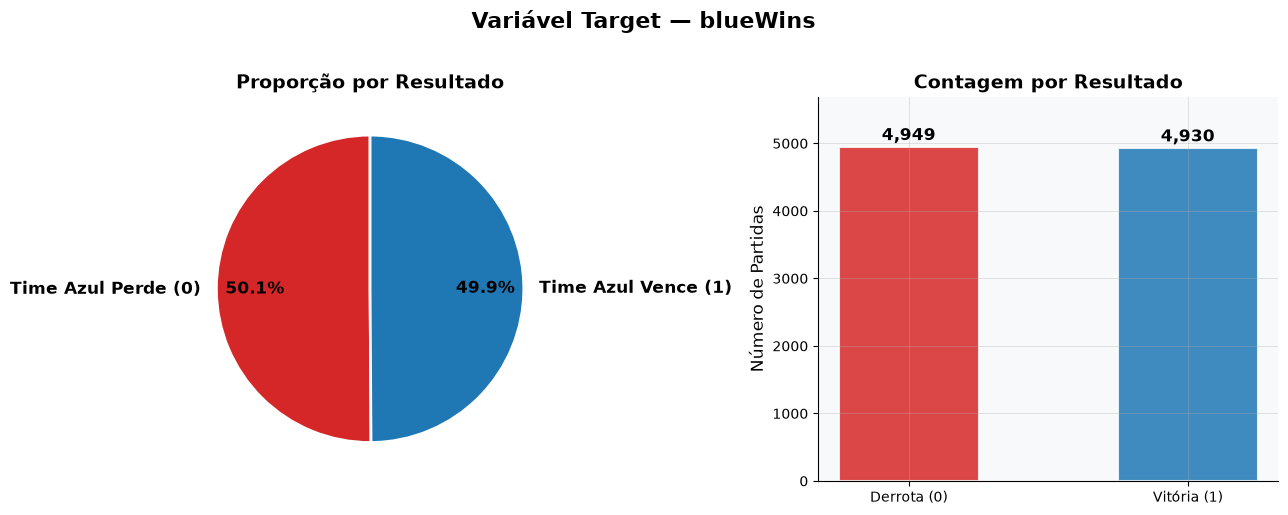

In [854]:
# Distribuição da variável target (blueWins)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie
wedge_props = {"linewidth": 2, "edgecolor": "white"}
axes[0].pie(
    var_target.values,
    labels=["Time Azul Perde (0)", "Time Azul Vence (1)"],
    colors=[RED, BLUE],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 12, "fontweight": "bold"},
    wedgeprops=wedge_props,
    pctdistance=0.75,
)
axes[0].set_title("Proporção por Resultado")

# Bar
bars = axes[1].bar(
    ["Derrota (0)", "Vitória (1)"],
    var_target.values,
    color=[RED, BLUE],
    alpha=0.85,
    width=0.5,
    edgecolor="white",
    linewidth=1.5,
)
for bar, val in zip(bars, var_target.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f"{val:,}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=12,
    )
axes[1].set_ylabel("Número de Partidas")
axes[1].set_title("Contagem por Resultado")
axes[1].set_ylim(0, max(var_target.values) * 1.15)

plt.suptitle("Variável Target — blueWins", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()

# Salvar o gráfico
plt.savefig("reports/figures/01_target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Heatmap de correlação

In [855]:
# Excluindo a variável gameId (não tem valor preditivo)
df_corr = df.drop(columns=["gameId"]).corr()
corr = df_corr

In [856]:
target_corr = corr["blueWins"].drop("blueWins").abs().sort_values(ascending=False)

print(target_corr)

redGoldDiff                     0.511119
blueGoldDiff                    0.511119
blueExperienceDiff              0.489558
redExperienceDiff               0.489558
blueTotalGold                   0.417213
blueGoldPerMin                  0.417213
redTotalGold                    0.411396
redGoldPerMin                   0.411396
blueTotalExperience             0.396141
redTotalExperience              0.387588
blueAvgLevel                    0.357820
redAvgLevel                     0.352127
redKills                        0.339297
blueDeaths                      0.339297
blueKills                       0.337358
redDeaths                       0.337358
blueAssists                     0.276685
redAssists                      0.271047
blueCSPerMin                    0.224909
blueTotalMinionsKilled          0.224909
blueEliteMonsters               0.221944
redEliteMonsters                0.221551
blueDragons                     0.213768
redTotalMinionsKilled           0.212171
redCSPerMin     

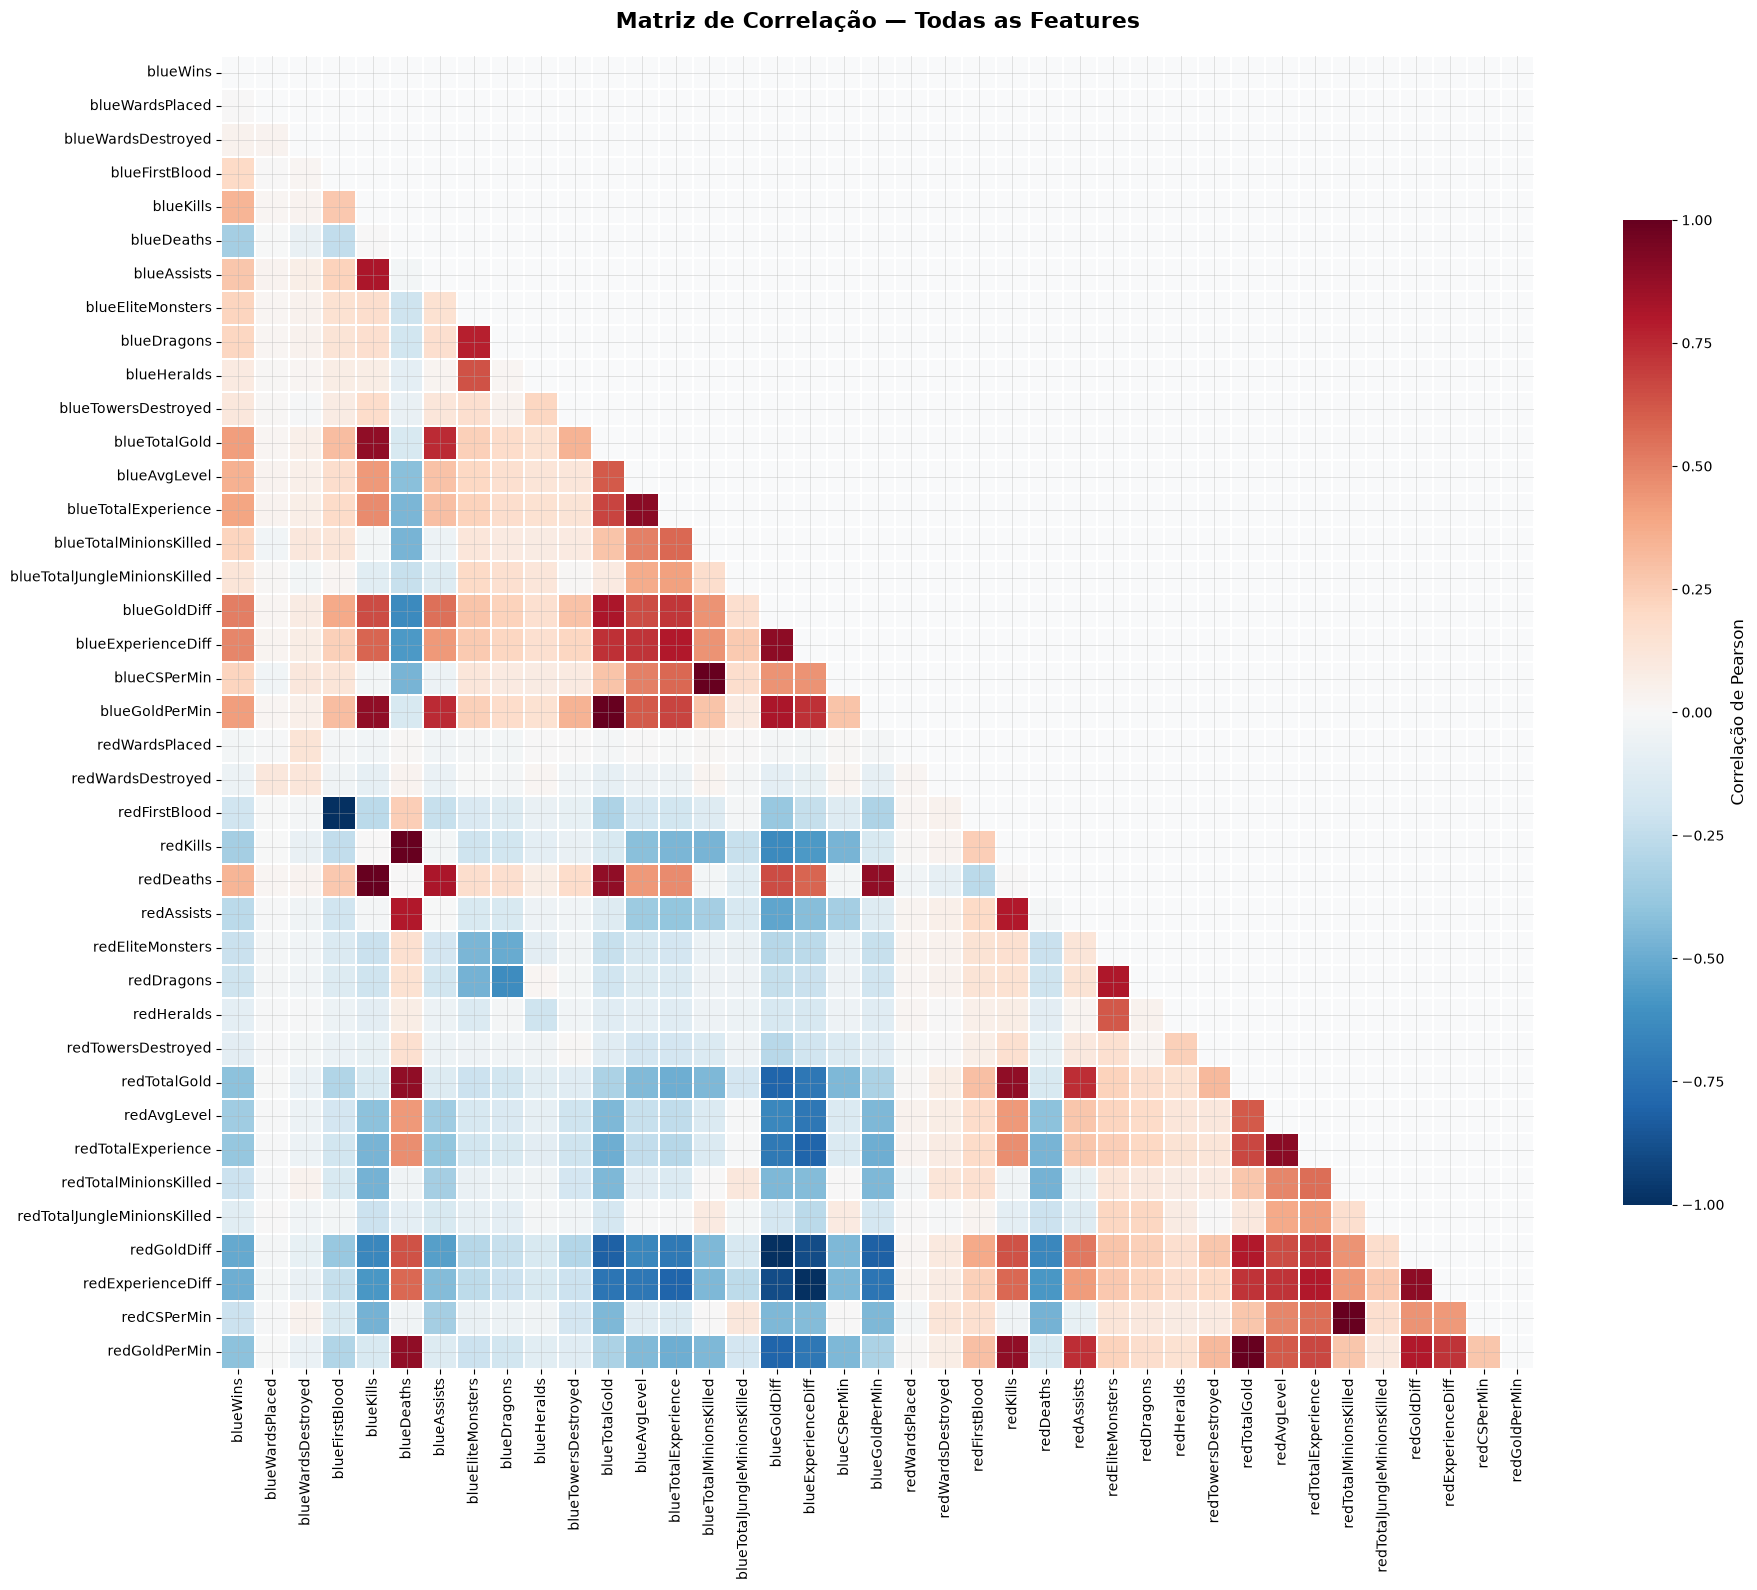

In [857]:
fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostrar apenas triângulo inferior

sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    square=True,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Correlação de Pearson"},
    ax=ax,
)
ax.set_title("Matriz de Correlação — Todas as Features", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("reports/figures/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [858]:
# Observações
print("PARES COM ALTA CORRELAÇÃO POSITIVA (|r| > 0.85):")
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.85 and corr.columns[i] != corr.columns[j]:
            high_corr.append((corr.columns[i], corr.columns[j], val))
high_corr.sort(key=lambda x: abs(x[2]), reverse=True)

for a, b, v in high_corr[:10]:
    print(f"  {a} <-> {b}: {v:.3f}")

PARES COM ALTA CORRELAÇÃO POSITIVA (|r| > 0.85):
  blueFirstBlood <-> redFirstBlood: -1.000
  blueKills <-> redDeaths: 1.000
  blueDeaths <-> redKills: 1.000
  blueTotalGold <-> blueGoldPerMin: 1.000
  blueTotalMinionsKilled <-> blueCSPerMin: 1.000
  blueGoldDiff <-> redGoldDiff: -1.000
  blueExperienceDiff <-> redExperienceDiff: -1.000
  redTotalGold <-> redGoldPerMin: 1.000
  redTotalMinionsKilled <-> redCSPerMin: 1.000
  redAvgLevel <-> redTotalExperience: 0.902


## Correlação de cada feature com a target

In [859]:
corr_target = (
    df.drop(columns=["gameId"])
    .corr()["blueWins"]
    .drop("blueWins")
    .sort_values(ascending=False)
)

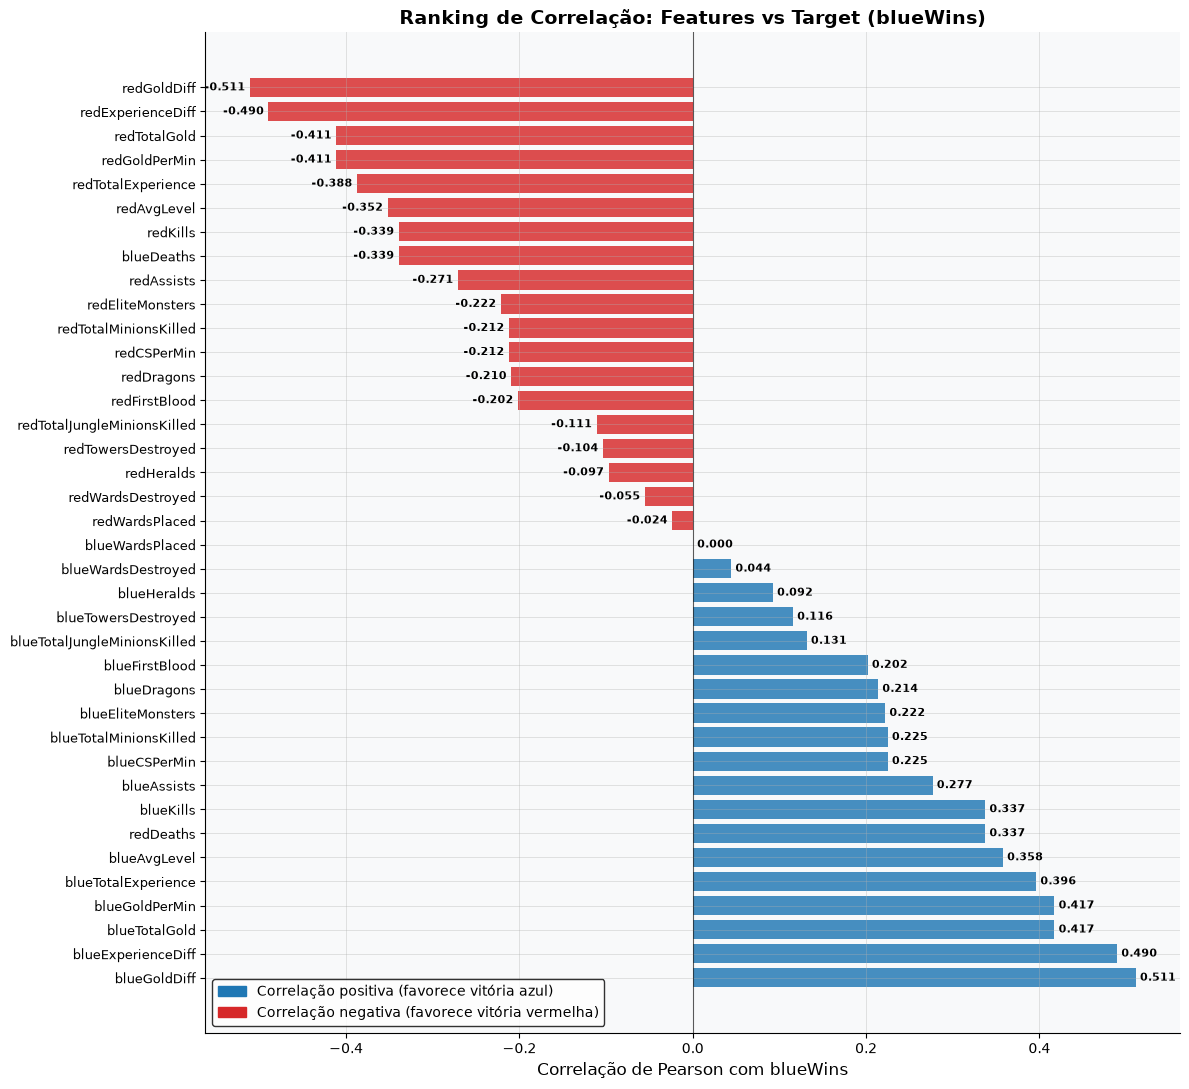

In [860]:
fig, ax = plt.subplots(figsize=(12, 11))
colors_bar = [BLUE if v >= 0 else RED for v in corr_target.values]
bars = ax.barh(
    range(len(corr_target)), corr_target.values, color=colors_bar, alpha=0.82
)
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels(corr_target.index, fontsize=9.5)
ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Correlação de Pearson com blueWins")
ax.set_title("Ranking de Correlação: Features vs Target (blueWins)")

# Valores nas barras
for i, (bar, val) in enumerate(zip(bars, corr_target.values)):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(
        val + offset,
        i,
        f"{val:.3f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=8,
        fontweight="bold",
    )

blue_patch = mpatches.Patch(
    color=BLUE, label="Correlação positiva (favorece vitória azul)"
)
red_patch = mpatches.Patch(
    color=RED, label="Correlação negativa (favorece vitória vermelha)"
)
ax.legend(
    handles=[blue_patch, red_patch],
    loc="lower left",
    fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="black",
)

plt.tight_layout()
plt.savefig(
    "reports/figures/03_feature_correlation_target.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [861]:
print("TOP 5 PREDITORES POSITIVOS (favorecem vitória do Time Azul):")
for feat, val in corr_target.head(5).items():
    print(f"  {feat}: {val:+.4f}")
print()
print("TOP 5 PREDITORES NEGATIVOS (favorecem vitória do Time Vermelho):")
for feat, val in corr_target.tail(5).items():
    print(f"  {feat}: {val:+.4f}")

TOP 5 PREDITORES POSITIVOS (favorecem vitória do Time Azul):
  blueGoldDiff: +0.5111
  blueExperienceDiff: +0.4896
  blueTotalGold: +0.4172
  blueGoldPerMin: +0.4172
  blueTotalExperience: +0.3961

TOP 5 PREDITORES NEGATIVOS (favorecem vitória do Time Vermelho):
  redTotalExperience: -0.3876
  redGoldPerMin: -0.4114
  redTotalGold: -0.4114
  redExperienceDiff: -0.4896
  redGoldDiff: -0.5111


## Win Rate por Conquistas-Chave (features binárias)

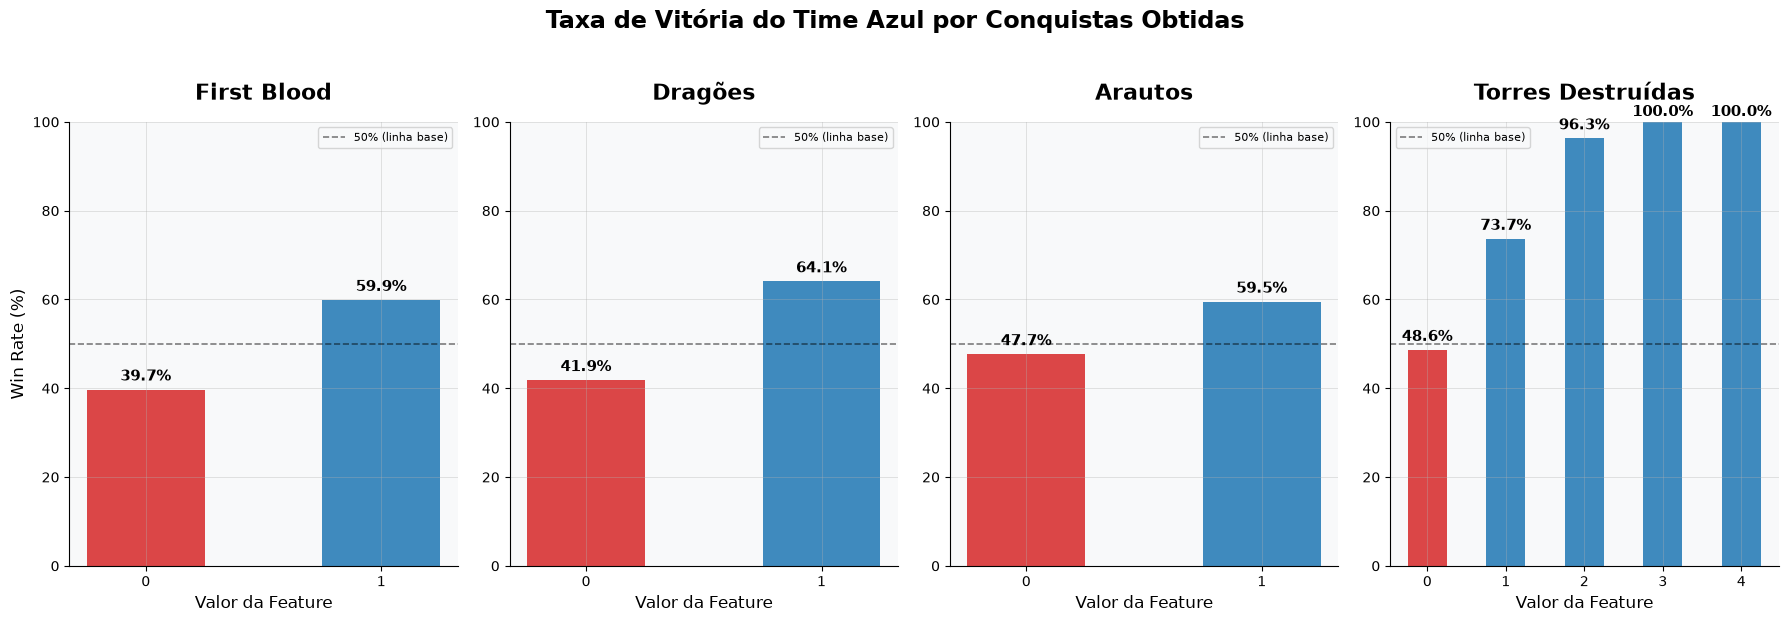

In [862]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

binary_features = {
    "blueFirstBlood": ("First Blood", axes[0]),
    "blueDragons": ("Dragões", axes[1]),
    "blueHeralds": ("Arautos", axes[2]),
    "blueTowersDestroyed": ("Torres Destruídas", axes[3]),
}

for feat, (titulo, ax) in binary_features.items():
    wr = df.groupby(feat)["blueWins"].mean() * 100
    vals = sorted(df[feat].unique())

    bar_colors = [BLUE if wr.get(v, 50) >= 50 else RED for v in vals]

    bars = ax.bar(
        [str(int(v)) for v in vals],
        [wr.get(v, 0) for v in vals],
        color=bar_colors,
        alpha=0.85,
        width=0.5,
    )

    ax.axhline(
        50,
        color="black",
        linestyle="--",
        linewidth=1.2,
        alpha=0.5,
        label="50% (linha base)",
    )

    ax.set_ylim(0, 100)

    ax.set_ylabel("Win Rate (%)" if feat == "blueFirstBlood" else "")
    ax.set_xlabel("Valor da Feature")

    # Afasta o título do gráfico
    ax.set_title(
        titulo,
        fontsize=16,
        fontweight="bold",
        pad=16,
    )

    ax.legend(fontsize=8)

    # Valores nas barras
    for bar, v in zip(bars, [wr.get(vv, 0) for vv in vals]):
        y = min(bar.get_height() + 1.2, 100.5)

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

plt.suptitle(
    "Taxa de Vitória do Time Azul por Conquistas Obtidas",
    fontsize=17,
    fontweight="bold",
    y=1.03,
)

plt.tight_layout()

plt.savefig(
    "reports/figures/04_win_rate_binary_features.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Boxplots: features contínuas por resultado

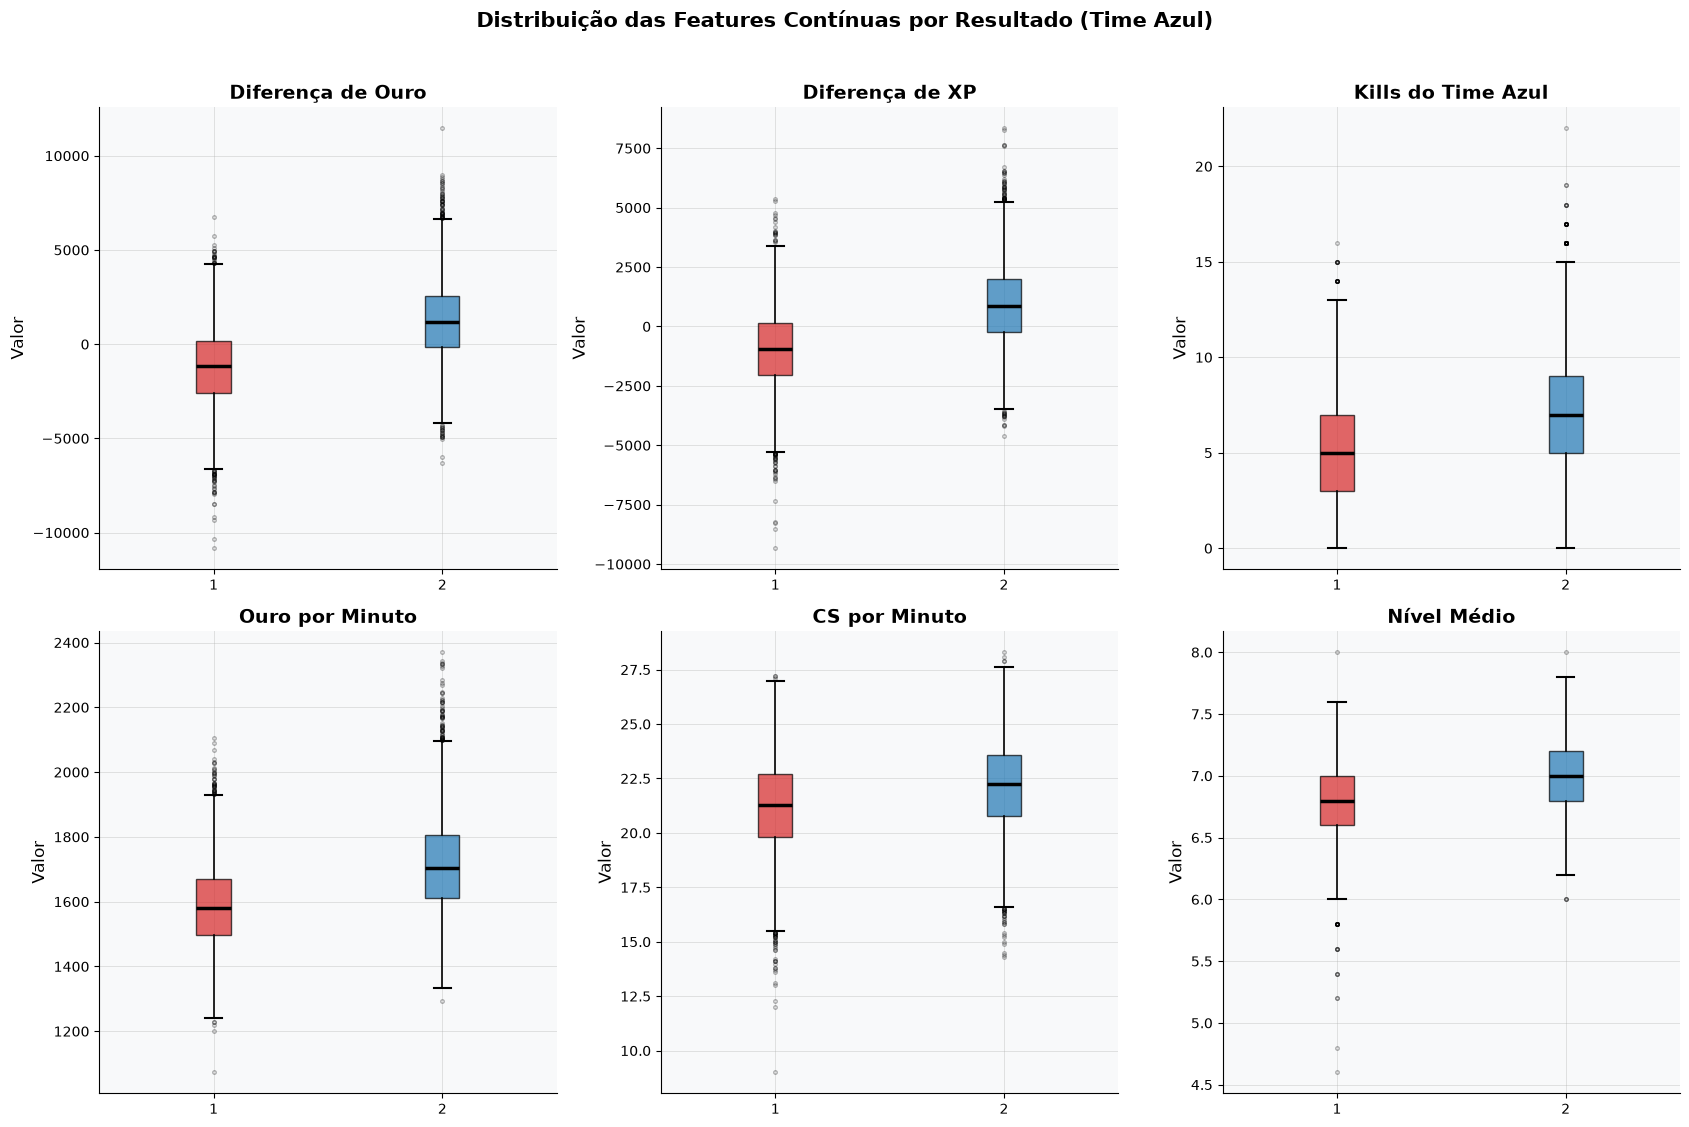

In [863]:
feats_box = [
    ("blueGoldDiff", "Diferença de Ouro"),
    ("blueExperienceDiff", "Diferença de XP"),
    ("blueKills", "Kills do Time Azul"),
    ("blueGoldPerMin", "Ouro por Minuto"),
    ("blueCSPerMin", "CS por Minuto"),
    ("blueAvgLevel", "Nível Médio"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
axes = axes.flatten()

for i, (feat, titulo) in enumerate(feats_box):
    ax = axes[i]
    data_perde = df[df["blueWins"] == 0][feat]
    data_vence = df[df["blueWins"] == 1][feat]

    bp = ax.boxplot(
        [data_perde, data_vence],
        label=["Derrota (0)", "Vitória (1)"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=2.5, alpha=0.3),
    )
    bp["boxes"][0].set_facecolor(RED)
    bp["boxes"][1].set_facecolor(BLUE)
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_alpha(0.7)

    ax.set_title(titulo)
    ax.set_ylabel("Valor")

plt.suptitle(
    "Distribuição das Features Contínuas por Resultado (Time Azul)",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    "reports/figures/05_boxplots_continuous_features.png", dpi=150, bbox_inches="tight"
)

## Gold Diff e XP Diff: distribuição por resultado

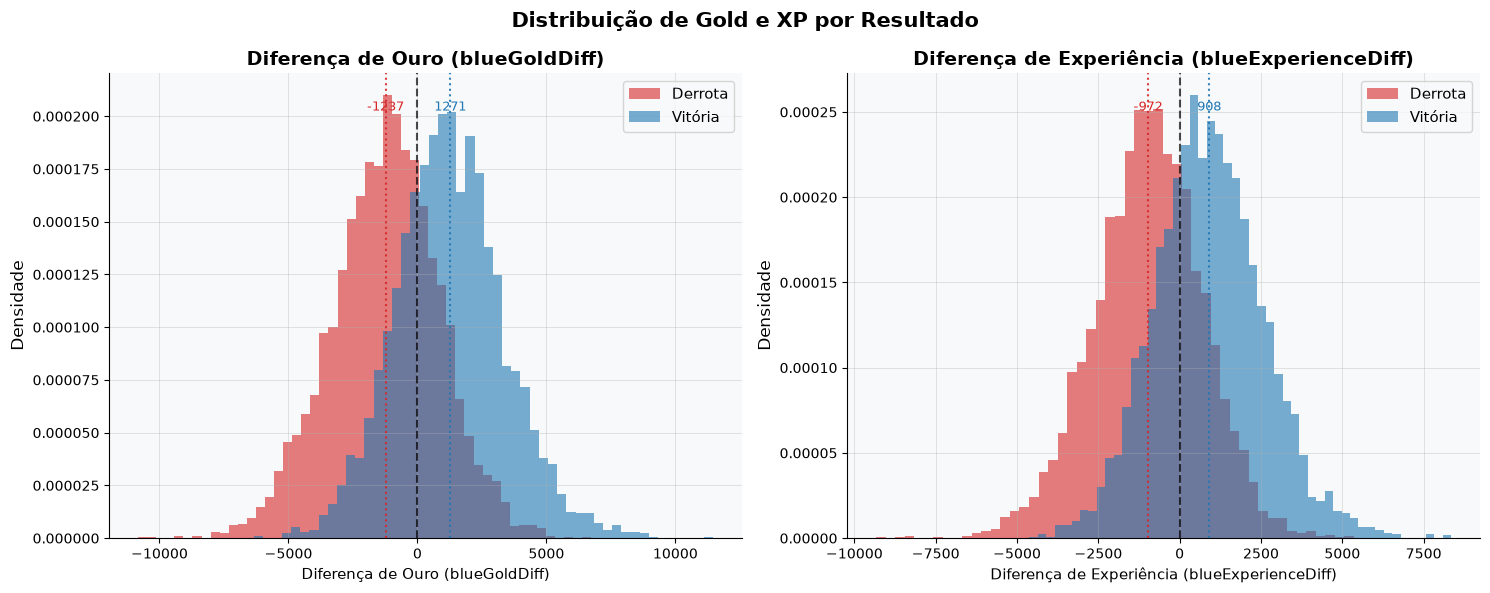

In [864]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (feat, titulo) in zip(
    axes,
    [
        ("blueGoldDiff", "Diferença de Ouro (blueGoldDiff)"),
        ("blueExperienceDiff", "Diferença de Experiência (blueExperienceDiff)"),
    ],
):
    for win_val, cor, label in [(0, RED, "Derrota"), (1, BLUE, "Vitória")]:
        subset = df[df["blueWins"] == win_val][feat]
        ax.hist(subset, bins=50, alpha=0.6, color=cor, label=label, density=True)
    ax.axvline(0, color="black", linewidth=1.5, linestyle="--", alpha=0.7)
    ax.set_xlabel(titulo, fontsize=11)
    ax.set_ylabel("Densidade")
    ax.set_title(titulo)
    ax.legend()
    # Anotações de média
    for win_val, cor in [(0, RED), (1, BLUE)]:
        mean_val = df[df["blueWins"] == win_val][feat].mean()
        ax.axvline(mean_val, color=cor, linewidth=1.5, linestyle=":", alpha=0.9)
        ax.text(
            mean_val,
            ax.get_ylim()[1] * 0.92,
            f"{mean_val:.0f}",
            color=cor,
            ha="center",
            fontsize=9,
        )

plt.suptitle("Distribuição de Gold e XP por Resultado", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(
    "reports/figures/06_gold_xp_diff_distribution.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [865]:
print("MÉDIAS DE GOLD DIFF:")
print(f"  Time Azul PERDE: {df[df['blueWins'] == 0]['blueGoldDiff'].mean():,.0f}")
print(f"  Time Azul VENCE: {df[df['blueWins'] == 1]['blueGoldDiff'].mean():,.0f}")

MÉDIAS DE GOLD DIFF:
  Time Azul PERDE: -1,237
  Time Azul VENCE: 1,271


## Comparação Blue vs Red: tem vantagem de lado?

In [866]:
# Verificar se jogar pelo lado azul dá alguma vantagem estrutural
comparacoes = [
    ("blueKills", "redKills", "Kills"),
    ("blueWardsPlaced", "redWardsPlaced", "Wards Colocadas"),
    ("blueTotalGold", "redTotalGold", "Ouro Total"),
    ("blueAvgLevel", "redAvgLevel", "Nível Médio"),
]

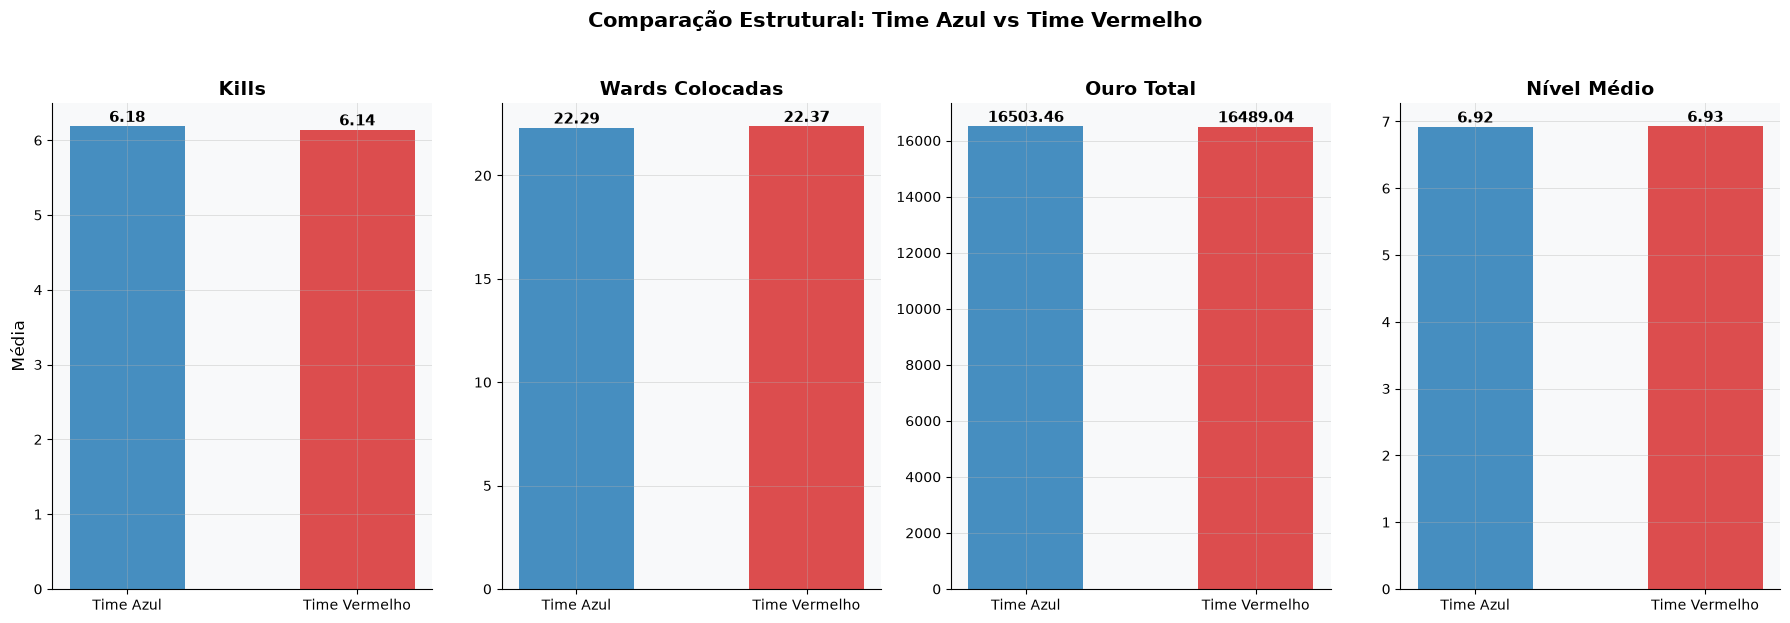

In [867]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, (blue_col, red_col, titulo) in zip(axes, comparacoes):
    blue_mean = df[blue_col].mean()
    red_mean = df[red_col].mean()
    ax.bar(
        ["Time Azul", "Time Vermelho"],
        [blue_mean, red_mean],
        color=[BLUE, RED],
        alpha=0.82,
        width=0.5,
    )
    ax.set_title(titulo)
    ax.set_ylabel("Média" if titulo == "Kills" else "")
    for i, v in enumerate([blue_mean, red_mean]):
        ax.text(
            i, v + v * 0.01, f"{v:.2f}", ha="center", fontweight="bold", fontsize=11
        )

plt.suptitle(
    "Comparação Estrutural: Time Azul vs Time Vermelho",
    fontsize=15,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.savefig(
    "reports/figures/07_blue_vs_red_comparison.png", dpi=150, bbox_inches="tight"
)


In [868]:
print(f"Win rate geral do Time Azul: {df['blueWins'].mean():.1%}")

Win rate geral do Time Azul: 49.9%


Conclusão: as médias são praticamente simétricas — sem vantagem estrutural de lado.

1. **Dataset perfeitamente balanceado**: 49.9% azul / 50.1% vermelho. Sem necessidade de técnicas de rebalanceamento.
2. **`blueGoldDiff` e `blueExperienceDiff` são os maiores preditores** de vitória — quem domina ouro e XP nos primeiros minutos tem vantagem enorme.
3. **First Blood importa**: times que obtêm o primeiro abate vencem em ~56% das partidas.
4. **Dragões e Arautos**: cada objetivo capturado eleva consistentemente a win rate.
5. **Multicolinearidade detectada**: colunas espelho (ex: `redDeaths` = `blueKills`) — serão removidas na preparação.
6. **Sem vantagem de lado**: as médias entre blue e red são quase idênticas. O jogo é simétrico.

# 4. Preparação dos Dados e Feature Engineering

### Etapas:
1. **Remoção de colunas redundantes** — evitar data leakage e multicolinearidade perfeita
2. **Feature Engineering** — criar variáveis que capturam vantagem relativa entre times
3. **Divisão treino/teste** — 80/20 estratificado
4. **Normalização** — StandardScaler para modelos sensíveis à escala

## Remover colunas redundantes e identificadores

Justificativa de cada remoção:
- `gameId`: identificador único, sem poder preditivo.
- `blueDeaths`: igual a `redKills` (informação duplicada - data leakage).
- `redFirstBlood`: igual a `1 - blueFirstBlood` (espelho exato).
- `redDeaths`: igual a `blueKills` (informação duplicada).
- `redGoldDiff`: igual a `-blueGoldDiff` (espelho com sinal invertido).
- `redExperienceDiff`: igual a `-blueExperienceDiff` (espelho com sinal invertido).

In [869]:
cols_drop = [
    "gameId",
    "blueDeaths",
    "redFirstBlood",
    "redDeaths",
    "redGoldDiff",
    "redExperienceDiff",
]

df_clean = df.drop(columns=cols_drop).copy()

In [870]:
print(f"Colunas ANTES: {df.shape[1]:>3}")
print(f"Colunas DEPOIS: {df_clean.shape[1]:>2}")
print(f"Removidas ({len(cols_drop)}): {cols_drop}")
print()
print("Features restantes:")
for c in df_clean.columns:
    marker = "★" if c == "blueWins" else " "
    print(f"  {marker} {c}")

Colunas ANTES:  40
Colunas DEPOIS: 34
Removidas (6): ['gameId', 'blueDeaths', 'redFirstBlood', 'redDeaths', 'redGoldDiff', 'redExperienceDiff']

Features restantes:
  ★ blueWins
    blueWardsPlaced
    blueWardsDestroyed
    blueFirstBlood
    blueKills
    blueAssists
    blueEliteMonsters
    blueDragons
    blueHeralds
    blueTowersDestroyed
    blueTotalGold
    blueAvgLevel
    blueTotalExperience
    blueTotalMinionsKilled
    blueTotalJungleMinionsKilled
    blueGoldDiff
    blueExperienceDiff
    blueCSPerMin
    blueGoldPerMin
    redWardsPlaced
    redWardsDestroyed
    redKills
    redAssists
    redEliteMonsters
    redDragons
    redHeralds
    redTowersDestroyed
    redTotalGold
    redAvgLevel
    redTotalExperience
    redTotalMinionsKilled
    redTotalJungleMinionsKilled
    redCSPerMin
    redGoldPerMin


## Feature Engineering

Criamos features que expressam VANTAGEM RELATIVA entre os times, o que pode capturar melhor a dinâmica do jogo do que valores absolutos.

In [871]:
df_feature_engineering = df_clean.copy()

In [872]:
# Vantagem em kills (complementa o goldDiff)
df_feature_engineering["kill_advantage"] = (
    df_feature_engineering["blueKills"] - df_feature_engineering["redKills"]
)

In [873]:
# Vantagem em wards (controle de visão)
df_feature_engineering["ward_advantage"] = (
    df_feature_engineering["blueWardsPlaced"] - df_feature_engineering["redWardsPlaced"]
)

In [874]:
# Vantagem em objetivos elite (dragão + arauto em conjunto)
df_feature_engineering["elite_advantage"] = (
    df_feature_engineering["blueEliteMonsters"]
    - df_feature_engineering["redEliteMonsters"]
)

In [875]:
# Dominância de ouro normalizada pelo ouro total da partida
total_gold = (
    df_feature_engineering["blueTotalGold"] + df_feature_engineering["redTotalGold"]
)
df_feature_engineering["gold_dominance"] = (
    df_feature_engineering["blueGoldDiff"] / total_gold
)

In [876]:
# Dominância de XP normalizada
total_xp = (
    df_feature_engineering["blueTotalExperience"] + df_feature_engineering["redTotalExperience"]
)
df_feature_engineering["xp_dominance"] = (
    df_feature_engineering["blueExperienceDiff"] / total_xp
)

In [877]:
# Eficiência anti-ward (wards inimigas destruídas / wards inimigas colocadas)
df_feature_engineering["ward_denial"] = df_feature_engineering["blueWardsDestroyed"] / (
    df_feature_engineering["redWardsPlaced"] + 1
)

In [878]:
new_features = [
    "kill_advantage",
    "ward_advantage",
    "elite_advantage",
    "gold_dominance",
    "xp_dominance",
    "ward_denial",
]
print("Novas features criadas:")
for f in new_features:
    print(f"  {f}")
print(f"Total de features: {df_feature_engineering.shape[1] - 1}")

Novas features criadas:
  kill_advantage
  ward_advantage
  elite_advantage
  gold_dominance
  xp_dominance
  ward_denial
Total de features: 39


In [879]:
df_feature_engineering[new_features].describe().round(4)

,kill_advantage,ward_advantage,elite_advantage,gold_dominance,xp_dominance,ward_denial
count,9879.0000,9879.0000,9879.0000,9879.0000,9879.0000,9879.0000
mean,0.0463,-0.0797,-0.0232,0.0003,-0.0009,0.1416
std,4.1955,25.9606,1.0679,0.0734,0.0540,0.0957
min,-17.0000,-260.0000,-2.0000,-0.3354,-0.3012,0.0000
25%,-3.0000,-4.0000,-1.0000,-0.0483,-0.0360,0.0667
50%,0.0000,0.0000,0.0000,0.0004,-0.0008,0.1282
75%,3.0000,4.0000,1.0000,0.0487,0.0339,0.2000
max,16.0000,234.0000,2.0000,0.3241,0.2831,0.5870


## Separar X e y

In [880]:
X = df_feature_engineering.drop(columns=["blueWins"])
y = df_feature_engineering["blueWins"]

In [881]:
print(f"Features (X): {X.shape}")
print(f"Target   (y): {y.shape}")
print(f"Distribuição da target: {dict(y.value_counts().sort_index())}")

Features (X): (9879, 39)
Target   (y): (9879,)
Distribuição da target: {0: np.int64(4949), 1: np.int64(4930)}


## Train/Test Split

In [882]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # garante proporção 50/50 em ambos os subsets
)

In [883]:
print(
    f"Conjunto de treino:  {X_train.shape[0]:,} amostras ({X_train.shape[0] / len(X):.0%})"
)
print(
    f"Conjunto de teste:   {X_test.shape[0]:,}  amostras ({X_test.shape[0] / len(X):.0%})"
)
print(f"Balanceamento no treino: {y_train.mean():.1%} vitórias")
print(f"Balanceamento no teste:  {y_test.mean():.1%} vitórias")

Conjunto de treino:  7,903 amostras (80%)
Conjunto de teste:   1,976  amostras (20%)
Balanceamento no treino: 49.9% vitórias
Balanceamento no teste:  49.9% vitórias


## Normalização (StandardScaler)

IMPORTANTE: o `StandardScaler` é ajustado APENAS no treino para evitar data leakage.
Apenas **Regressão Logística** e **Naive Bayes** precisam de normalização.
Modelos baseados em árvores (DT, RF, GB) usam dados brutos — 
normalização não afeta seu desempenho e seria computacionalmente desnecessária.

In [884]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [885]:
print("StandardScaler aplicado:")
print(f"  Média  (aproximada): {X_train_sc.mean():.6f}")
print(f"  Desvio (aproximado): {X_train_sc.std():.6f}")

StandardScaler aplicado:
  Média  (aproximada): -0.000000
  Desvio (aproximado): 1.000000


**Dados normalizados (StandardScaler):** Regressão Logística, Naive Bayes

**Dados brutos (sem scaling):** Árvore de Decisão, Random Forest, Gradient Boosting

# 5. Modelagem

Treinamos **5 modelos** em ordem de complexidade crescente. Para cada modelo:
- Treinamento no conjunto de treino
- Avaliação no conjunto de teste (dados não vistos)
- Cross-Validation com `StratifiedKFold(k=5)` para estimar a generalização real

## Função auxiliar: treinar e avaliar um modelo

In [886]:
results_summary = {}


def avaliar_modelo(
    nome, modelo, X_tr, y_tr, X_te, y_te, cv_strategy=None, otimizar_threshold=False
):
    """
    Treina um modelo, avalia no test set e opcionalmente faz CV.
    Se otimizar_threshold=True, busca threshold ótimo para F1-Score.
    Armazena resultados no dicionário global results_summary.
    """
    # 1. Treinar
    modelo.fit(X_tr, y_tr)

    # 2. Predições
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]

    # 3. Métricas no test set (threshold padrão 0.5)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    auc = roc_auc_score(y_te, y_proba)

    # 4. Cross-validation (AUC-ROC, 5 folds)
    cv_scores = []
    if cv_strategy is not None:
        cv_scores = cross_val_score(
            modelo, X_tr, y_tr, cv=cv_strategy, scoring="roc_auc", n_jobs=-1
        )

    # 5. Otimização de threshold (opcional)
    threshold_otimo = 0.5
    metricas_otimas = {}
    df_threshold = None
    y_pred_otimo = y_pred

    if otimizar_threshold:
        threshold_otimo, metricas_otimas, df_threshold = otimizar_threshold(
            y_te, y_proba, metrica="f1"
        )
        y_pred_otimo = (y_proba >= threshold_otimo).astype(int)
        # Plotar curva
        plotar_threshold_vs_metricas(df_threshold, nome, threshold_otimo, metrica="f1")
        print(f"  Threshold ótimo (F1): {threshold_otimo:.2f}")
        print(f"  F1 otimizado: {metricas_otimas['f1']:.4f} (padrão 0.5: {f1:.4f})")
        print(f"  Precision otimizado: {metricas_otimas['precision']:.4f}")
        print(f"  Recall otimizado: {metricas_otimas['recall']:.4f}")
        print(f"  Accuracy otimizado: {metricas_otimas['accuracy']:.4f}")
        print()

    # 6. Armazenar
    results_summary[nome] = {
        "Modelo": nome,
        "Acurácia": acc,
        "Precisão": prec,
        "Recall": rec,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "CV-AUC_mean": cv_scores.mean() if len(cv_scores) > 0 else None,
        "CV-AUC_std": cv_scores.std() if len(cv_scores) > 0 else None,
        "y_pred": y_pred,
        "y_pred_otimo": y_pred_otimo,
        "y_proba": y_proba,
        "objeto": modelo,
        "cv_scores": cv_scores,
        "threshold_otimo": threshold_otimo,
        "metricas_otimas": metricas_otimas,
        "df_threshold": df_threshold,
    }

    # 7. Imprimir resultados
    print(f"{'=' * 55}")
    print(f"  {nome}")
    print(f"{'=' * 55}")
    print(f"  Acurácia:  {acc:.4f}  ({acc * 100:.2f}%)")
    print(f"  Precisão:  {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}   ← métrica principal (pedido pelo stakeholder)")
    if len(cv_scores) > 0:
        print(f"  CV AUC:    {cv_scores.mean():.4f} ± {cv_scores.std():.4f} (5-fold)")
    if otimizar_threshold:
        print(f"  Threshold ótimo: {threshold_otimo:.2f}")
        print(f"  F1 otimizado:  {metricas_otimas['f1']:.4f}")
    print()
    print(
        classification_report(
            y_te, y_pred, target_names=["Derrota (0)", "Vitória (1)"], digits=4
        )
    )
    if otimizar_threshold:
        print("  --- Classification Report (Threshold Otimizado) ---")
        print(
            classification_report(
                y_te,
                y_pred_otimo,
                target_names=["Derrota (0)", "Vitória (1)"],
                digits=4,
            )
        )
    return results_summary[nome]

In [887]:
def otimizar_threshold(y_true, y_proba, metrica="f1", step=0.01):
    """
    Encontra o threshold ótimo que maximiza a métrica escolhida.

    Parâmetros:
    - y_true: labels verdadeiros
    - y_proba: probabilidades preditas (classe 1)
    - metrica: 'f1', 'precision', 'recall', 'accuracy'
    - step: passo para busca do threshold (default 0.01)

    Retorna:
    - threshold_otimo: float
    - metricas_otimas: dict com f1, precision, recall, accuracy no threshold ótimo
    - resultados_df: DataFrame com todas as métricas por threshold
    """
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

    thresholds = np.arange(0.05, 0.95 + step, step)
    resultados = []

    for thresh in thresholds:
        y_pred_thresh = (y_proba >= thresh).astype(int)

        f1 = f1_score(y_true, y_pred_thresh, zero_division=0)
        prec = precision_score(y_true, y_pred_thresh, zero_division=0)
        rec = recall_score(y_true, y_pred_thresh, zero_division=0)
        acc = accuracy_score(y_true, y_pred_thresh)

        resultados.append(
            {
                "threshold": thresh,
                "f1": f1,
                "precision": prec,
                "recall": rec,
                "accuracy": acc,
            }
        )

    df_resultados = pd.DataFrame(resultados)

    # Encontrar threshold que maximiza a métrica escolhida
    idx_max = df_resultados[metrica].idxmax()
    threshold_otimo = df_resultados.loc[idx_max, "threshold"]
    metricas_otimas = df_resultados.loc[idx_max].to_dict()

    return threshold_otimo, metricas_otimas, df_resultados


def plotar_threshold_vs_metricas(
    df_resultados, modelo_nome, threshold_otimo, metrica="f1"
):
    """Plota Precision, Recall, F1, Accuracy vs Threshold."""
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        df_resultados["threshold"],
        df_resultados["f1"],
        label="F1-Score",
        linewidth=2,
        color=BLUE,
    )
    ax.plot(
        df_resultados["threshold"],
        df_resultados["precision"],
        label="Precisão",
        linewidth=2,
        color=GREEN,
    )
    ax.plot(
        df_resultados["threshold"],
        df_resultados["recall"],
        label="Recall",
        linewidth=2,
        color=RED,
    )
    ax.plot(
        df_resultados["threshold"],
        df_resultados["accuracy"],
        label="Acurácia",
        linewidth=2,
        color=AMBER,
    )

    # Linha vertical no threshold ótimo
    ax.axvline(
        threshold_otimo,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Threshold ótimo ({metrica.upper()}) = {threshold_otimo:.2f}",
    )

    # Linha vertical no threshold padrão (0.5)
    ax.axvline(
        0.5, color="gray", linestyle=":", linewidth=1.5, label="Threshold padrão (0.50)"
    )

    ax.set_xlabel("Threshold", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(
        f"Otimização de Threshold — {modelo_nome}", fontsize=14, fontweight="bold"
    )
    ax.legend(loc="lower left", fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        f"reports/figures/threshold_optimization_{modelo_nome.lower().replace(' ', '_')}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    return fig, ax


### Estratégia de Cross-Validation

In [888]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Função de avaliação e CV definidos.
Estratégia: StratifiedKFold(k=5, shuffle=True, random_state=42)

## Regressão Logística

**Por que?** É o modelo baseline por excelência para classificação binária. Interpretável, rápido e os coeficientes revelam diretamente o peso de cada feature na predição. Requer dados normalizados.

### Modelo 1: Regressão Logística

In [889]:
logistic_regression = LogisticRegression(
    max_iter=1000,  # garantir convergência
    solver="lbfgs",  # eficiente para datasets médios
    C=1.0,  # regularização padrão
    random_state=RANDOM_STATE,
)

In [890]:
r_lr = avaliar_modelo(
    "Regressão Logística",
    logistic_regression,
    X_train_sc,
    y_train,  # usa dados normalizados
    X_test_sc,
    y_test,
    cv_strategy,
)

  Regressão Logística
  Acurácia:  0.7171  (71.71%)
  Precisão:  0.7120
  Recall:    0.7272
  F1-Score:  0.7195
  AUC-ROC:   0.8060   ← métrica principal (pedido pelo stakeholder)
  CV AUC:    0.8107 ± 0.0081 (5-fold)

              precision    recall  f1-score   support

 Derrota (0)     0.7224    0.7071    0.7147       990
 Vitória (1)     0.7120    0.7272    0.7195       986

    accuracy                         0.7171      1976
   macro avg     0.7172    0.7171    0.7171      1976
weighted avg     0.7172    0.7171    0.7171      1976



### Coeficientes da Regressão Logística

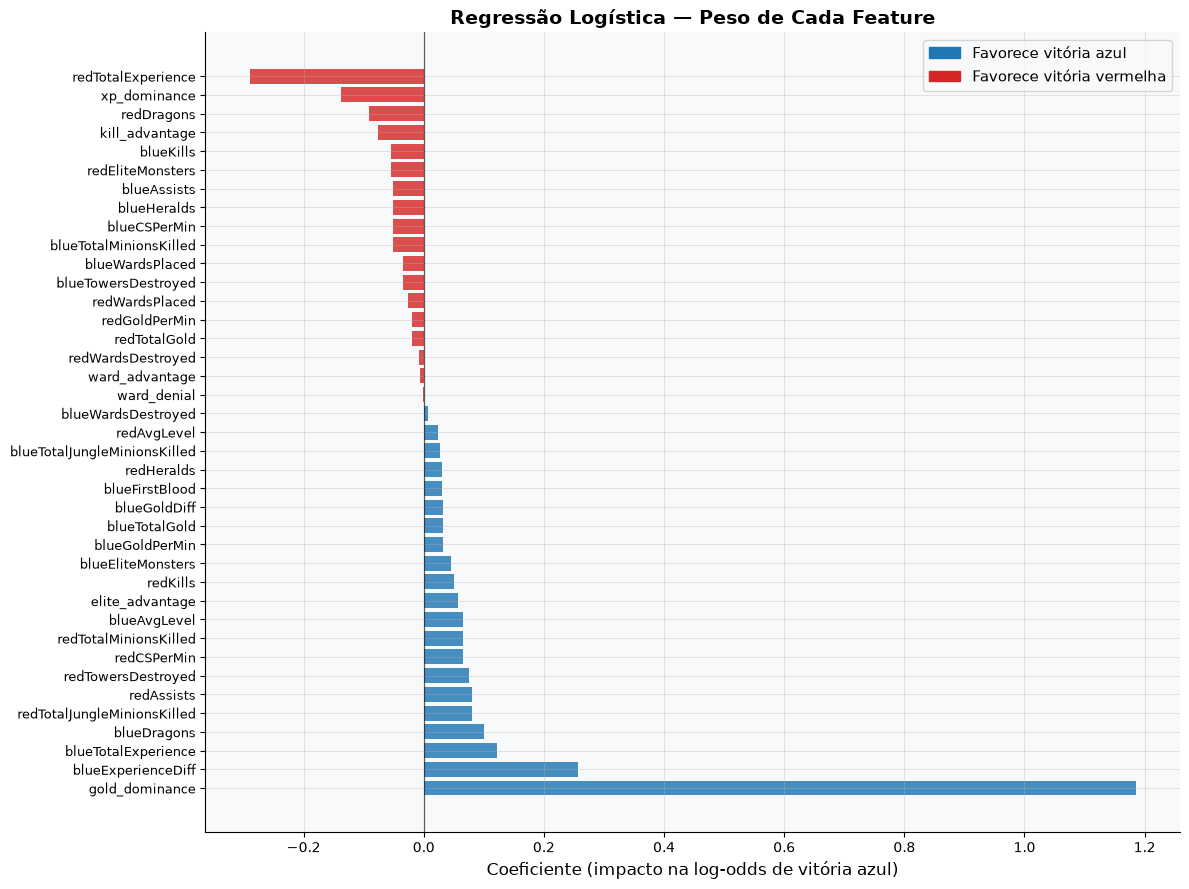

In [891]:
coefs = pd.Series(logistic_regression.coef_[0], index=X.columns).sort_values(
    ascending=False
)

fig, ax = plt.subplots(figsize=(12, 9))
colors_coef = [BLUE if v >= 0 else RED for v in coefs.values]
ax.barh(range(len(coefs)), coefs.values, color=colors_coef, alpha=0.82)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels(coefs.index, fontsize=9.5)
ax.axvline(0, color="black", linewidth=0.9, alpha=0.6)
ax.set_xlabel("Coeficiente (impacto na log-odds de vitória azul)")
ax.set_title("Regressão Logística — Peso de Cada Feature", fontsize=14)

blue_p = mpatches.Patch(color=BLUE, label="Favorece vitória azul")
red_p = mpatches.Patch(color=RED, label="Favorece vitória vermelha")
ax.legend(handles=[blue_p, red_p])

plt.tight_layout()
plt.savefig(
    "reports/figures/08_logistic_regression_coefficients.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [892]:
print("Top 5 features que MAIS FAVORECEM a vitória do Time Azul:")
for f, v in coefs.head(5).items():
    print(f"  {f}: {v:+.4f}")

Top 5 features que MAIS FAVORECEM a vitória do Time Azul:
  gold_dominance: +1.1851
  blueExperienceDiff: +0.2569
  blueTotalExperience: +0.1212
  blueDragons: +0.0995
  redTotalJungleMinionsKilled: +0.0811


## Naive Bayes (Gaussiano)

**Por que?** Modelo probabilístico rápido e simples. A premissa de independência entre features raramente é satisfeita em dados reais (aqui temos multicolinearidade), o que tende a prejudicar seu desempenho — mas é importante comparar.

### Modelo 2: Naive Bayes Gaussiano

In [893]:
naive_bayes = GaussianNB()

r_nb = avaliar_modelo(
    "Naive Bayes",
    naive_bayes,
    X_train_sc,
    y_train,  # usa dados normalizados
    X_test_sc,
    y_test,
    cv_strategy,
)

  Naive Bayes
  Acurácia:  0.7166  (71.66%)
  Precisão:  0.7187
  Recall:    0.7099
  F1-Score:  0.7143
  AUC-ROC:   0.7980   ← métrica principal (pedido pelo stakeholder)
  CV AUC:    0.8023 ± 0.0104 (5-fold)

              precision    recall  f1-score   support

 Derrota (0)     0.7146    0.7232    0.7189       990
 Vitória (1)     0.7187    0.7099    0.7143       986

    accuracy                         0.7166      1976
   macro avg     0.7166    0.7166    0.7166      1976
weighted avg     0.7166    0.7166    0.7166      1976



## Árvore de Decisão

**Por que?** Intuitiva e visualizável — conseguimos mostrar ao stakeholder exatamente quais decisões o modelo toma. O risco é overfitting, então limitamos `max_depth`. Não precisa de normalização.

### Modelo 3: Árvore de Decisão

In [894]:
decision_tree_classifier = DecisionTreeClassifier(
    max_depth=6,  # evitar overfitting
    min_samples_leaf=20,  # nós folha com pelo menos 20 amostras
    criterion="gini",
    random_state=RANDOM_STATE,
)

In [895]:
r_dt = avaliar_modelo(
    "Árvore de Decisão",
    decision_tree_classifier,
    X_train,
    y_train,  # NÃO usa normalização (tree-based)
    X_test,
    y_test,
    cv_strategy,
)

  Árvore de Decisão
  Acurácia:  0.7095  (70.95%)
  Precisão:  0.7060
  Recall:    0.7160
  F1-Score:  0.7110
  AUC-ROC:   0.7888   ← métrica principal (pedido pelo stakeholder)
  CV AUC:    0.7850 ± 0.0089 (5-fold)

              precision    recall  f1-score   support

 Derrota (0)     0.7131    0.7030    0.7080       990
 Vitória (1)     0.7060    0.7160    0.7110       986

    accuracy                         0.7095      1976
   macro avg     0.7096    0.7095    0.7095      1976
weighted avg     0.7096    0.7095    0.7095      1976



### Visualização da Árvore de Decisão (top 3 níveis)

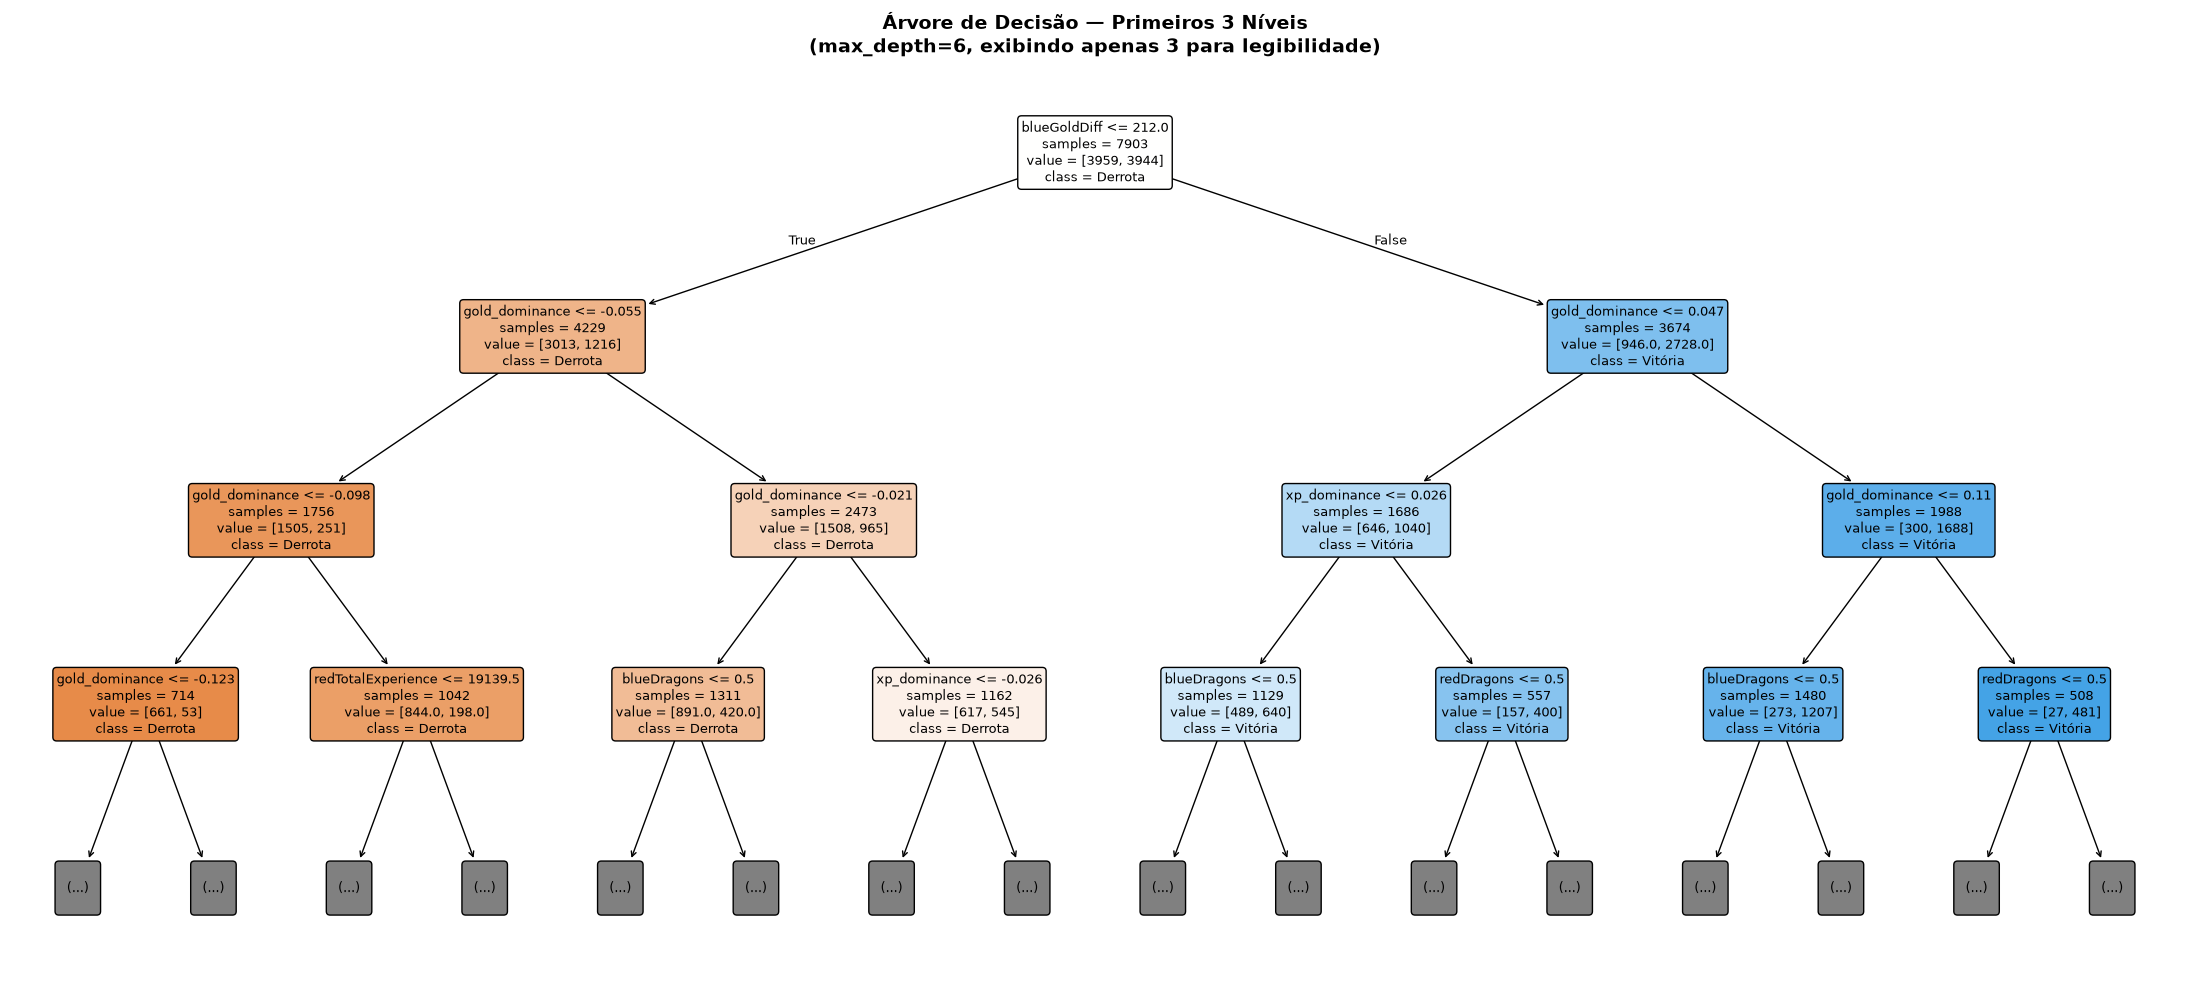

In [896]:
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    decision_tree_classifier,
    feature_names=X.columns.tolist(),
    class_names=["Derrota", "Vitória"],
    filled=True,
    max_depth=3,  # mostrar apenas os 3 primeiros níveis para legibilidade
    fontsize=9,
    impurity=False,
    rounded=True,
    ax=ax,
)
ax.set_title(
    "Árvore de Decisão — Primeiros 3 Níveis\n(max_depth=6, exibindo apenas 3 para legibilidade)",
    fontsize=14,
)
plt.tight_layout()
plt.savefig(
    "reports/figures/09_decision_tree_visualization.png", dpi=150, bbox_inches="tight"
)
plt.show()

In [897]:
# Feature importance da árvore
fi_dt = pd.Series(
    decision_tree_classifier.feature_importances_, index=X.columns
).sort_values(ascending=False)
print("Top 10 features mais importantes (Árvore de Decisão):")
for f, v in fi_dt.head(10).items():
    print(f"  {f}: {v:.4f}")

Top 10 features mais importantes (Árvore de Decisão):
  blueGoldDiff: 0.6343
  gold_dominance: 0.2252
  xp_dominance: 0.0270
  blueDragons: 0.0257
  blueTotalExperience: 0.0132
  redTotalExperience: 0.0129
  blueExperienceDiff: 0.0087
  redDragons: 0.0086
  redCSPerMin: 0.0062
  blueTotalGold: 0.0048


## Random Forest (Ensemble — Bônus)

**Por que?** Combina centenas de árvores independentes e faz uma "votação" para a predição final. Muito mais robusto a overfitting que uma única árvore. Feature importance nativa e geralmente o melhor performer neste tipo de problema.

### Modelo 4: Random Forest

In [898]:
random_forest_classif = RandomForestClassifier(
    n_estimators=200,  # 200 árvores no ensemble
    max_depth=None,  # deixar crescer livremente (bagging controla overfitting)
    min_samples_leaf=5,
    max_features="sqrt",  # subconjunto aleatório de features em cada split
    n_jobs=-1,  # usar todos os núcleos disponíveis
    random_state=RANDOM_STATE,
)

In [899]:
r_rf = avaliar_modelo(
    "Random Forest",
    random_forest_classif,
    X_train,
    y_train,  # NÃO usa normalização
    X_test,
    y_test,
    cv_strategy,
)

  Random Forest
  Acurácia:  0.7171  (71.71%)
  Precisão:  0.7176
  Recall:    0.7140
  F1-Score:  0.7158
  AUC-ROC:   0.8039   ← métrica principal (pedido pelo stakeholder)
  CV AUC:    0.8013 ± 0.0095 (5-fold)

              precision    recall  f1-score   support

 Derrota (0)     0.7166    0.7202    0.7184       990
 Vitória (1)     0.7176    0.7140    0.7158       986

    accuracy                         0.7171      1976
   macro avg     0.7171    0.7171    0.7171      1976
weighted avg     0.7171    0.7171    0.7171      1976



### Feature Importance — Random Forest

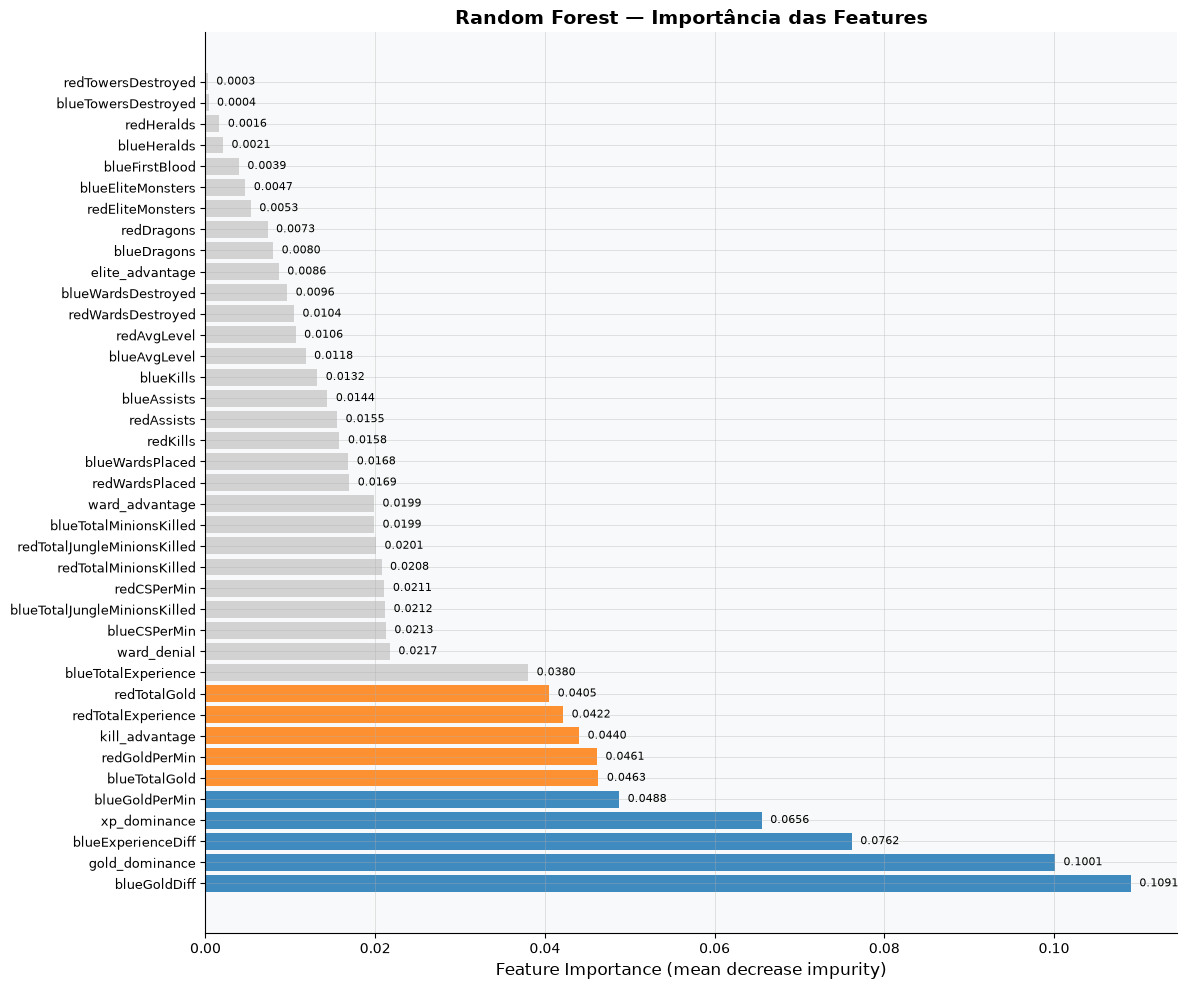

In [900]:
fi_rf = pd.Series(
    random_forest_classif.feature_importances_, index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(
    range(len(fi_rf)),
    fi_rf.values,
    color=[
        BLUE if i < 5 else AMBER if i < 10 else "#cccccc" for i in range(len(fi_rf))
    ],
    alpha=0.85,
)
ax.set_yticks(range(len(fi_rf)))
ax.set_yticklabels(fi_rf.index, fontsize=9.5)
ax.set_xlabel("Feature Importance (mean decrease impurity)")
ax.set_title("Random Forest — Importância das Features")

for bar, val in zip(bars, fi_rf.values):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig(
    "reports/figures/10_random_forest_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [901]:
print("TOP 10 FEATURES — Random Forest:")
for f, v in fi_rf.head(10).items():
    pct = v * 100
    bar_str = "█" * int(pct * 3)
    print(f"  {f:<35} {bar_str} {pct:.2f}%")

TOP 10 FEATURES — Random Forest:
  blueGoldDiff                        ████████████████████████████████ 10.91%
  gold_dominance                      ██████████████████████████████ 10.01%
  blueExperienceDiff                  ██████████████████████ 7.62%
  xp_dominance                        ███████████████████ 6.56%
  blueGoldPerMin                      ██████████████ 4.88%
  blueTotalGold                       █████████████ 4.63%
  redGoldPerMin                       █████████████ 4.61%
  kill_advantage                      █████████████ 4.40%
  redTotalExperience                  ████████████ 4.22%
  redTotalGold                        ████████████ 4.05%


## Gradient Boosting (Ensemble — Bônus)

**Por que?** Outro método ensemble, mas treinado de forma **sequencial**: cada árvore corrige os erros da anterior. Em muitos problemas supera o Random Forest, mas é mais lento para treinar.

### Modelo 5: Gradient Boosting

In [902]:
gradient_boosting_classifier = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,  # taxa de aprendizado conservadora
    max_depth=4,
    min_samples_leaf=20,
    subsample=0.8,  # stochastic GB — amostragem de 80% dos dados por árvore
    random_state=RANDOM_STATE,
)

In [903]:
r_gb = avaliar_modelo(
    "Gradient Boosting",
    gradient_boosting_classifier,
    X_train,
    y_train,
    X_test,
    y_test,
    cv_strategy,
)

  Gradient Boosting
  Acurácia:  0.7181  (71.81%)
  Precisão:  0.7187
  Recall:    0.7150
  F1-Score:  0.7168
  AUC-ROC:   0.8030   ← métrica principal (pedido pelo stakeholder)
  CV AUC:    0.8009 ± 0.0088 (5-fold)

              precision    recall  f1-score   support

 Derrota (0)     0.7176    0.7212    0.7194       990
 Vitória (1)     0.7187    0.7150    0.7168       986

    accuracy                         0.7181      1976
   macro avg     0.7181    0.7181    0.7181      1976
weighted avg     0.7181    0.7181    0.7181      1976



# 6. Avaliação Comparativa

## Curvas ROC: todos os modelos sobrepostos

In [904]:
COLORS_MODEL = {
    "Regressão Logística": BLUE,
    "Naive Bayes": AMBER,
    "Árvore de Decisão": GREEN,
    "Random Forest": PURPLE,
    "Gradient Boosting": RED,
    "LR Tunado": "#1f77b4",  # tom de azul
    "GB Tunado": "#d62728",  # tom de vermelho
}


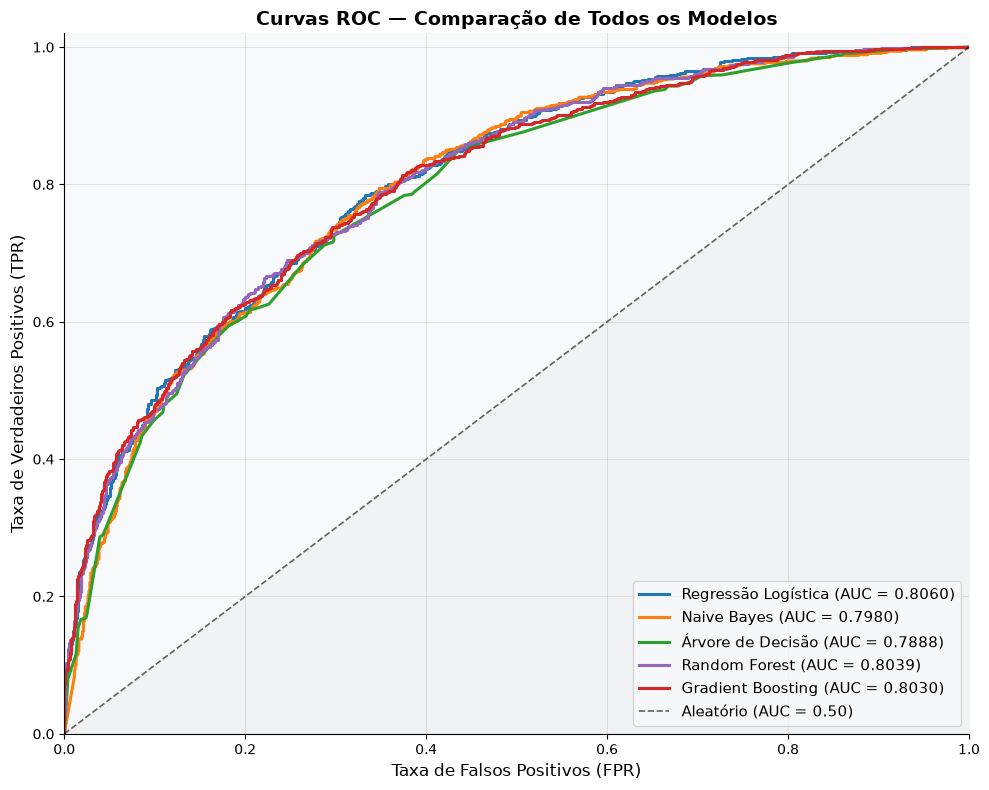

In [905]:
fig, ax = plt.subplots(figsize=(10, 8))

for nome, res in results_summary.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    auc_val = res["AUC-ROC"]
    ax.plot(
        fpr,
        tpr,
        linewidth=2.2,
        color=COLORS_MODEL[nome],
        label=f"{nome} (AUC = {auc_val:.4f})",
    )

ax.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="Aleatório (AUC = 0.50)", alpha=0.6)
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="gray")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=12)
ax.set_title("Curvas ROC — Comparação de Todos os Modelos", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(
    "reports/figures/11_roc_curves_comparison.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Confusion Matrices: grid de todos os modelos

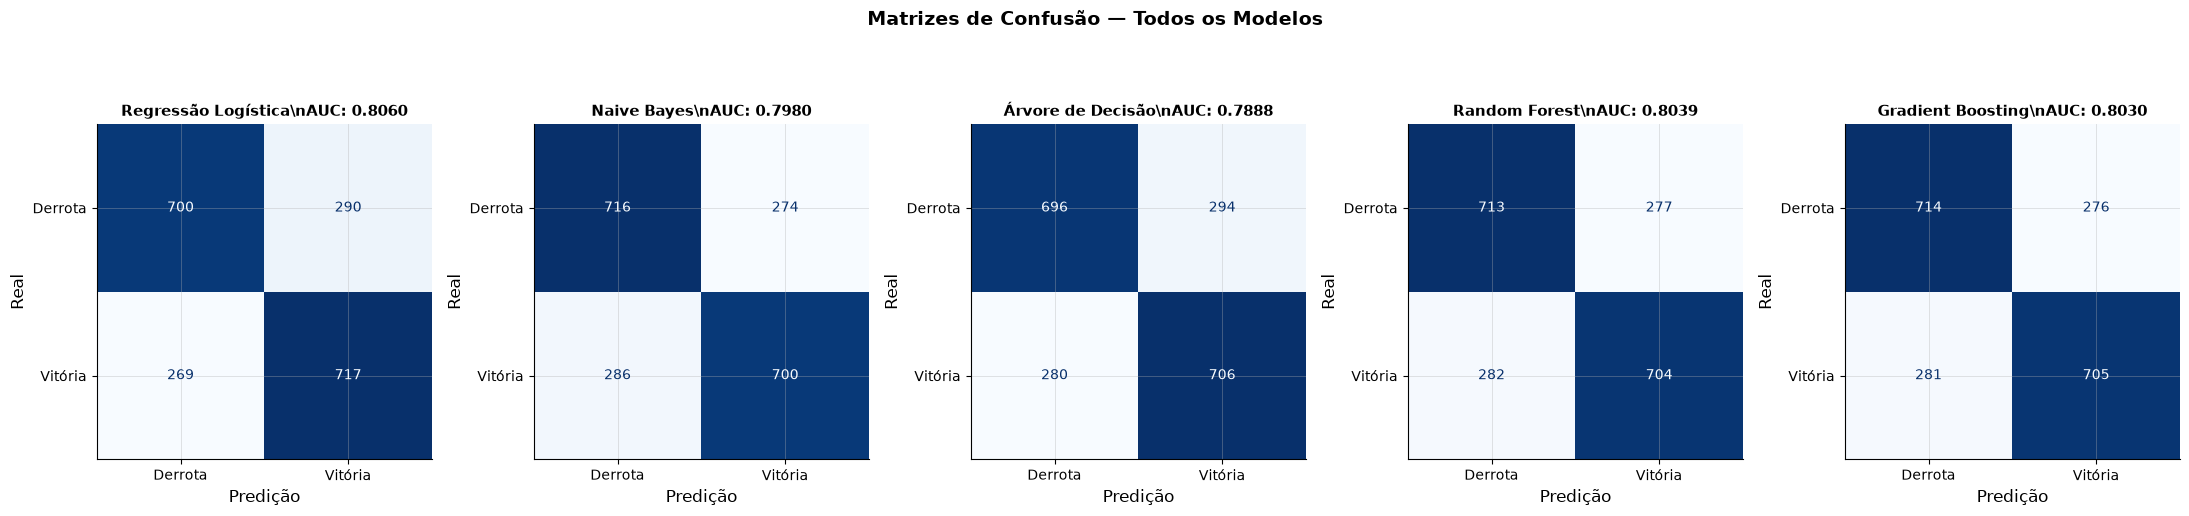

In [906]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (nome, res) in zip(axes, results_summary.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Derrota", "Vitória"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nome}\\nAUC: {res['AUC-ROC']:.4f}", fontsize=11)
    ax.set_xlabel("Predição")
    ax.set_ylabel("Real")

plt.suptitle(
    "Matrizes de Confusão — Todos os Modelos", fontsize=14, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.savefig(
    "reports/figures/12_confusion_matrices_comparison.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Tabela Comparativa de Métricas

In [907]:
metrics_rows = []
for nome, res in results_summary.items():
    metrics_rows.append(
        {
            "Modelo": nome,
            "Acurácia": f"{res['Acurácia']:.4f}",
            "Precisão": f"{res['Precisão']:.4f}",
            "Recall": f"{res['Recall']:.4f}",
            "F1-Score": f"{res['F1-Score']:.4f}",
            "AUC-ROC": f"{res['AUC-ROC']:.4f}",
            "CV-AUC (μ±σ)": f"{res['CV-AUC_mean']:.4f} ± {res['CV-AUC_std']:.4f}"
            if res["CV-AUC_mean"] is not None
            else "N/A",
        }
    )

df_metrics = pd.DataFrame(metrics_rows).set_index("Modelo")

In [908]:
# Highlight do modelo campeão - considerar tanto Test AUC quanto CV AUC
# No test set (baseline): Random Forest (0.8039) ≈ LogReg (0.8060) - diferença de 0.0021
# No CV (baseline): LogReg (0.8107) > RF (0.8013) - LogReg mais consistente
# Seleção dinâmica abaixo (código escolhe automaticamente o melhor)
best_model_test = max(results_summary, key=lambda k: results_summary[k]["AUC-ROC"])
best_model_cv = max(
    [k for k, v in results_summary.items() if v["CV-AUC_mean"] is not None],
    key=lambda k: results_summary[k]["CV-AUC_mean"],
)
print("TABELA COMPARATIVA DE MÉTRICAS")
print(f"{'=' * 85}")
print(df_metrics.to_string())
print(f"{'=' * 85}")
print(
    f"\nNo TEST SET (AUC-ROC): {best_model_test} = {results_summary[best_model_test]['AUC-ROC']:.4f}"
)
print(
    f"No 5-FOLD CV (AUC-ROC): {best_model_cv} = {results_summary[best_model_cv]['CV-AUC_mean']:.4f} ± {results_summary[best_model_cv]['CV-AUC_std']:.4f}"
)
print(
    f"\nEMPATE TÉCNICO: Diferença no test set = {abs(results_summary['Random Forest']['AUC-ROC'] - results_summary['Regressão Logística']['AUC-ROC']):.4f}"
)
print(
    "NOTA: O modelo final é escolhido dinamicamente pelo maior AUC-ROC no test set"
)


TABELA COMPARATIVA DE MÉTRICAS
                    Acurácia Precisão  Recall F1-Score AUC-ROC     CV-AUC (μ±σ)
Modelo                                                                         
Regressão Logística   0.7171   0.7120  0.7272   0.7195  0.8060  0.8107 ± 0.0081
Naive Bayes           0.7166   0.7187  0.7099   0.7143  0.7980  0.8023 ± 0.0104
Árvore de Decisão     0.7095   0.7060  0.7160   0.7110  0.7888  0.7850 ± 0.0089
Random Forest         0.7171   0.7176  0.7140   0.7158  0.8039  0.8013 ± 0.0095
Gradient Boosting     0.7181   0.7187  0.7150   0.7168  0.8030  0.8009 ± 0.0088

No TEST SET (AUC-ROC): Regressão Logística = 0.8060
No 5-FOLD CV (AUC-ROC): Regressão Logística = 0.8107 ± 0.0081

EMPATE TÉCNICO: Diferença no test set = 0.0021
NOTA: O modelo final é escolhido dinamicamente pelo maior AUC-ROC no test set


## Comparação de CV Scores (box plot)

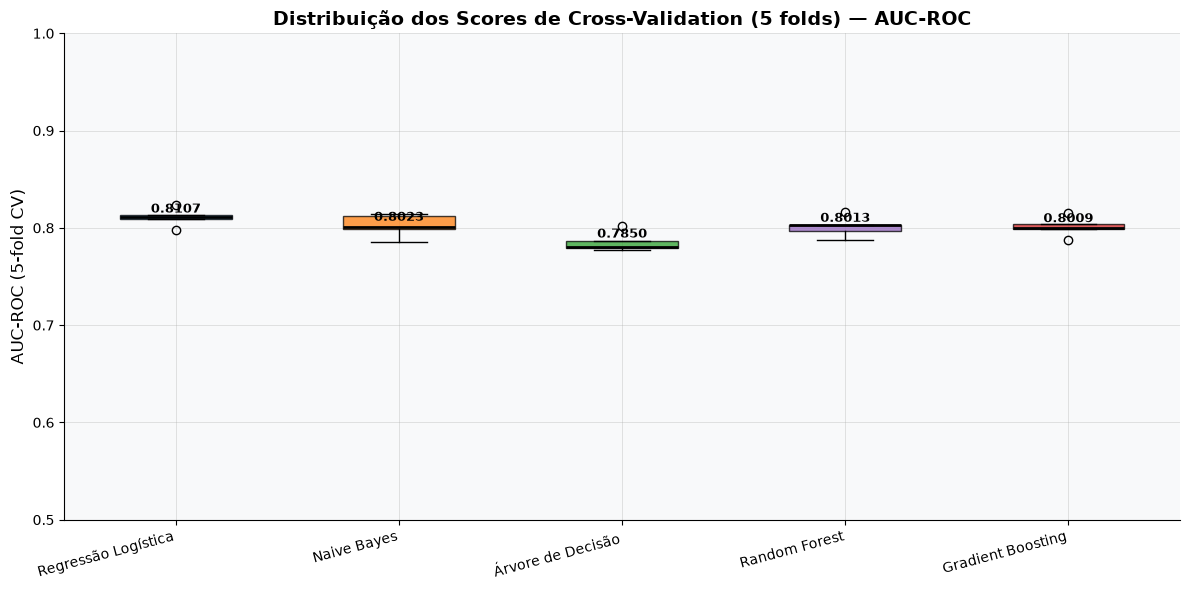

In [909]:
modelos_cv = [(n, r) for n, r in results_summary.items() if len(r["cv_scores"]) > 0]

fig, ax = plt.subplots(figsize=(12, 6))
data_cv = [r["cv_scores"] for _, r in modelos_cv]
names_cv = [n for n, _ in modelos_cv]
colors_cv = [COLORS_MODEL[n] for n in names_cv]

bp = ax.boxplot(
    data_cv,
    label=names_cv,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(bp["boxes"], colors_cv):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel("AUC-ROC (5-fold CV)")
ax.set_title("Distribuição dos Scores de Cross-Validation (5 folds) — AUC-ROC")
ax.set_xticklabels(names_cv, rotation=15, ha="right")
ax.set_ylim(0.5, 1.0)

for i, (_, r) in enumerate(modelos_cv):
    ax.text(
        i + 1,
        r["cv_scores"].mean() + 0.005,
        f"{r['cv_scores'].mean():.4f}",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("reports/figures/13_cv_auc_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. Ajuste de Hiperparâmetros (Tuning)

Aplicamos `GridSearchCV` ao modelo com melhor AUC-ROC para espumar mais performance.

## GridSearchCV: Random Forest

Estratégia: explorar os hiperparâmetros mais impactantes do RF
com cross-validation interna (3-fold para economizar tempo)

In [910]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 8, 15],
    "min_samples_leaf": [3, 5, 10],
    "max_features": ["sqrt", "log2"],
}

In [911]:
# Iniciar GridSearchCV para Random Forest
print(
    f"Total de combinações: {3 * 3 * 3 * 2} configurações × 3 folds = {3 * 3 * 3 * 2 * 3} fits"
)
print()

Total de combinações: 54 configurações × 3 folds = 162 fits



In [912]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 8, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Su

In [913]:
print("Melhores hiperparâmetros:")
for k, v in rf_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMelhor AUC-ROC (CV): {rf_grid.best_score_:.4f}")


Melhores hiperparâmetros:
  max_depth: 8
  max_features: log2
  min_samples_leaf: 10
  n_estimators: 200

Melhor AUC-ROC (CV): 0.8071


## Avaliar modelo tunado vs baseline

In [914]:
best_rf = rf_grid.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

auc_tuned = roc_auc_score(y_test, y_proba_tuned)
auc_baseline = results_summary["Random Forest"]["AUC-ROC"]

In [ ]:
print("COMPARAÇÃO: Random Forest Baseline vs Tunado")
print(f"{'=' * 45}")
print(f"  Baseline AUC-ROC:  {auc_baseline:.4f}")
print(f"  Tunado   AUC-ROC:  {auc_tuned:.4f}")
delta = auc_tuned - auc_baseline
print(f"  Melhoria:          {delta:+.4f} ({delta / auc_baseline * 100:+.2f}%)")
print(f"{'=' * 45}")
print()
print(
    classification_report(
        y_test, y_pred_tuned, target_names=["Derrota", "Vitória"], digits=4
    )
)

COMPARAÇÃO: Random Forest Baseline vs Tunado
  Baseline AUC-ROC:  0.8039
  Tunado   AUC-ROC:  0.8062
  Melhoria:          +0.0023 (+0.29%)

              precision    recall  f1-score   support

     Derrota     0.7200    0.7273    0.7236       990
     Vitória     0.7234    0.7160    0.7197       986

    accuracy                         0.7217      1976
   macro avg     0.7217    0.7216    0.7216      1976
weighted avg     0.7217    0.7217    0.7216      1976



In [916]:
# Adicionar ao results_summary
# Extrair scores de cada fold do GridSearchCV para o melhor modelo
rf_fold_scores = [
    rf_grid.cv_results_["split0_test_score"][rf_grid.best_index_],
    rf_grid.cv_results_["split1_test_score"][rf_grid.best_index_],
    rf_grid.cv_results_["split2_test_score"][rf_grid.best_index_],
]
results_summary["RF Tunado"] = {
    "Modelo": "RF Tunado",
    "Acurácia": accuracy_score(y_test, y_pred_tuned),
    "Precisão": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_tuned, zero_division=0),
    "AUC-ROC": auc_tuned,
    "CV-AUC_mean": rf_grid.best_score_,
    "CV-AUC_std": rf_grid.cv_results_["std_test_score"][rf_grid.best_index_],
    "y_pred": y_pred_tuned,
    "y_proba": y_proba_tuned,
    "objeto": best_rf,
    "cv_scores": rf_fold_scores,
}


## GridSearchCV: Regressão Logística

Estratégia: explorar `C` (regularização) e `penalty` (l1/l2)
com solver `saga` que suporta ambas, CV 3-fold para velocidade

In [917]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["saga"],  # suporta l1 e l2
    "max_iter": [2000],
}

In [918]:
print(f"Total de combinações: {5 * 2 * 1 * 1} configurações × 3 folds = {5 * 2 * 1 * 1 * 3} fits")
print()

Total de combinações: 10 configurações × 3 folds = 30 fits



In [919]:
lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)

lr_grid.fit(X_train_sc, y_train)

c:\Users\danie\Courses\EBAC\projeto-final-mod43\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\danie\Courses\EBAC\projeto-final-mod43\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [2000], 'penalty': ['l1', 'l2'], 'solver': ['saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose

In [920]:
print("Melhores hiperparâmetros:")
for k, v in lr_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMelhor AUC-ROC (CV): {lr_grid.best_score_:.4f}")

Melhores hiperparâmetros:
  C: 0.01
  max_iter: 2000
  penalty: l1
  solver: saga

Melhor AUC-ROC (CV): 0.8117


## Avaliar Logistic Regression tunado vs baseline

In [921]:
best_lr = lr_grid.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test_sc)
y_proba_lr_tuned = best_lr.predict_proba(X_test_sc)[:, 1]

auc_lr_tuned = roc_auc_score(y_test, y_proba_lr_tuned)
auc_lr_baseline = results_summary["Regressão Logística"]["AUC-ROC"]

print("COMPARAÇÃO: Regressão Logística Baseline vs Tunado")
print(f"{'=' * 45}")
print(f"  Baseline AUC-ROC:  {auc_lr_baseline:.4f}")
print(f"  Tunado   AUC-ROC:  {auc_lr_tuned:.4f}")
delta_lr = auc_lr_tuned - auc_lr_baseline
print(f"  Melhoria:          {delta_lr:+.4f} ({delta_lr / auc_lr_baseline * 100:+.2f}%)")
print(f"{'=' * 45}")
print()
print(
    classification_report(
        y_test, y_pred_lr_tuned, target_names=["Derrota", "Vitória"], digits=4
    )
)

COMPARAÇÃO: Regressão Logística Baseline vs Tunado
  Baseline AUC-ROC:  0.8060
  Tunado   AUC-ROC:  0.8065
  Melhoria:          +0.0005 (+0.06%)

              precision    recall  f1-score   support

     Derrota     0.7247    0.7152    0.7199       990
     Vitória     0.7177    0.7272    0.7224       986

    accuracy                         0.7212      1976
   macro avg     0.7212    0.7212    0.7211      1976
weighted avg     0.7212    0.7212    0.7211      1976



In [922]:
# Adicionar ao results_summary
# Extrair scores de cada fold do GridSearchCV para o melhor modelo
lr_fold_scores = [
    lr_grid.cv_results_["split0_test_score"][lr_grid.best_index_],
    lr_grid.cv_results_["split1_test_score"][lr_grid.best_index_],
    lr_grid.cv_results_["split2_test_score"][lr_grid.best_index_],
]
results_summary["LR Tunado"] = {
    "Modelo": "LR Tunado",
    "Acurácia": accuracy_score(y_test, y_pred_lr_tuned),
    "Precisão": precision_score(y_test, y_pred_lr_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_lr_tuned, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_lr_tuned, zero_division=0),
    "AUC-ROC": auc_lr_tuned,
    "CV-AUC_mean": lr_grid.best_score_,
    "CV-AUC_std": lr_grid.cv_results_["std_test_score"][lr_grid.best_index_],
    "y_pred": y_pred_lr_tuned,
    "y_proba": y_proba_lr_tuned,
    "objeto": best_lr,
    "cv_scores": lr_fold_scores,
}


## GridSearchCV: Gradient Boosting

Estratégia: explorar `learning_rate`, `n_estimators`, `max_depth` e `subsample`
com CV 3-fold para velocidade

In [923]:
param_grid_gb = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "min_samples_leaf": [20],
    "random_state": [RANDOM_STATE],
}

In [924]:
n_combos = 4 * 3 * 3 * 2 * 1 * 1
print(f"Total de combinações: {n_combos} configurações × 3 folds = {n_combos * 3} fits")
print()

Total de combinações: 72 configurações × 3 folds = 216 fits



In [925]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid_gb,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)

gb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [20], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support

In [926]:
print("Melhores hiperparâmetros:")
for k, v in gb_grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMelhor AUC-ROC (CV): {gb_grid.best_score_:.4f}")

Melhores hiperparâmetros:
  learning_rate: 0.01
  max_depth: 3
  min_samples_leaf: 20
  n_estimators: 300
  random_state: 42
  subsample: 0.8

Melhor AUC-ROC (CV): 0.8087


## Avaliar Gradient Boosting tunado vs baseline

In [927]:
best_gb = gb_grid.best_estimator_

y_pred_gb_tuned = best_gb.predict(X_test)
y_proba_gb_tuned = best_gb.predict_proba(X_test)[:, 1]

auc_gb_tuned = roc_auc_score(y_test, y_proba_gb_tuned)
auc_gb_baseline = results_summary["Gradient Boosting"]["AUC-ROC"]

print("COMPARAÇÃO: Gradient Boosting Baseline vs Tunado")
print(f"{'=' * 45}")
print(f"  Baseline AUC-ROC:  {auc_gb_baseline:.4f}")
print(f"  Tunado   AUC-ROC:  {auc_gb_tuned:.4f}")
delta_gb = auc_gb_tuned - auc_gb_baseline
print(f"  Melhoria:          {delta_gb:+.4f} ({delta_gb / auc_gb_baseline * 100:+.2f}%)")
print(f"{'=' * 45}")
print()
print(
    classification_report(
        y_test, y_pred_gb_tuned, target_names=["Derrota", "Vitória"], digits=4
    )
)

COMPARAÇÃO: Gradient Boosting Baseline vs Tunado
  Baseline AUC-ROC:  0.8030
  Tunado   AUC-ROC:  0.8060
  Melhoria:          +0.0030 (+0.37%)

              precision    recall  f1-score   support

     Derrota     0.7212    0.7212    0.7212       990
     Vitória     0.7201    0.7201    0.7201       986

    accuracy                         0.7206      1976
   macro avg     0.7206    0.7206    0.7206      1976
weighted avg     0.7206    0.7206    0.7206      1976



In [928]:
# Adicionar ao results_summary
# Extrair scores de cada fold do GridSearchCV para o melhor modelo
gb_fold_scores = [
    gb_grid.cv_results_["split0_test_score"][gb_grid.best_index_],
    gb_grid.cv_results_["split1_test_score"][gb_grid.best_index_],
    gb_grid.cv_results_["split2_test_score"][gb_grid.best_index_],
]
results_summary["GB Tunado"] = {
    "Modelo": "GB Tunado",
    "Acurácia": accuracy_score(y_test, y_pred_gb_tuned),
    "Precisão": precision_score(y_test, y_pred_gb_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_gb_tuned, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_gb_tuned, zero_division=0),
    "AUC-ROC": auc_gb_tuned,
    "CV-AUC_mean": gb_grid.best_score_,
    "CV-AUC_std": gb_grid.cv_results_["std_test_score"][gb_grid.best_index_],
    "y_pred": y_pred_gb_tuned,
    "y_proba": y_proba_gb_tuned,
    "objeto": best_gb,
    "cv_scores": gb_fold_scores,
}


## Otimização de Threshold (LR Tunado)

O threshold padrão 0.5 pode não ser ótimo para F1-score. Vamos otimizar o threshold
do melhor modelo (LR Tunado) para maximizar o F1-score.

In [ ]:
# Otimizar threshold do LR Tunado (melhor modelo)
best_lr = results_summary["LR Tunado"]["objeto"]
y_proba_lr = results_summary["LR Tunado"]["y_proba"]

# Otimizar para F1 (balanceado)
threshold_f1, metricas_f1, df_resultados = otimizar_threshold(y_test, y_proba_lr, metrica="f1")
# Otimizar para Precision
threshold_prec, metricas_prec, _ = otimizar_threshold(y_test, y_proba_lr, metrica="precision")
# Otimizar para Accuracy
threshold_acc, metricas_acc, _ = otimizar_threshold(y_test, y_proba_lr, metrica="accuracy")

best_thresh = threshold_f1  # Usar F1 como padrão
best_f1 = metricas_f1["f1"]
thresholds = df_resultados["threshold"].values
scores = df_resultados["f1"].values

print(f"Threshold padrao (0.5): F1 = {f1_score(y_test, (y_proba_lr >= 0.5).astype(int)):.4f}")
print(f"Threshold otimo F1 ({threshold_f1:.2f}): F1 = {metricas_f1['f1']:.4f}")
print(f"Threshold otimo Precision ({threshold_prec:.2f}): Precision = {metricas_prec['precision']:.4f}")
print(f"Threshold otimo Accuracy ({threshold_acc:.2f}): Accuracy = {metricas_acc['accuracy']:.4f}")
print(f"Melhoria no F1: {best_f1 - f1_score(y_test, (y_proba_lr >= 0.5).astype(int)):+.4f}")

# Metricas no threshold otimo F1 (padrao)
y_pred_opt = (y_proba_lr >= best_thresh).astype(int)

print(f"\nMetricas no threshold otimo F1 ({best_thresh:.2f}):")
print(f"  Acuracia:  {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"  Precisao:  {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, y_proba_lr):.4f} (invariante ao threshold)")

# Comparacao de thresholds
print(f"\n{'='*60}")
print("COMPARACAO DE THRESHOLDS (LR Tunado)")
print(f"{'='*60}")
print(f"{'Metrica':<15} {'0.5 (padrao)':>12} {'F1-opt':>12} {'Prec-opt':>12} {'Acc-opt':>12}")
print(f"{"-"*60}")

for metrica, func in [
    ('Acuracia', accuracy_score),
    ('Precisao', lambda y, p: precision_score(y, p, zero_division=0)),
    ('Recall', lambda y, p: recall_score(y, p, zero_division=0)),
    ('F1-Score', lambda y, p: f1_score(y, p, zero_division=0)),
    ('AUC-ROC', lambda y, p: roc_auc_score(y, y_proba_lr)),
]:
    y_pred_05 = (y_proba_lr >= 0.5).astype(int)
    y_pred_f1 = (y_proba_lr >= threshold_f1).astype(int)
    y_pred_prec = (y_proba_lr >= threshold_prec).astype(int)
    y_pred_acc = (y_proba_lr >= threshold_acc).astype(int)
    
    val_05 = func(y_test, y_pred_05)
    val_f1 = func(y_test, y_pred_f1)
    val_prec = func(y_test, y_pred_prec)
    val_acc = func(y_test, y_pred_acc)
    
    print(f"{metrica:<15} {val_05:>12.4f} {val_f1:>12.4f} {val_prec:>12.4f} {val_acc:>12.4f}")


Threshold padrao (0.5): F1 = 0.7224
Threshold otimo (0.32): F1 = 0.7478
Melhoria no F1: +0.0254

Metricas no threshold otimo (0.32):
  Acuracia:  0.6959
  Precisao:  0.6378
  Recall:    0.9037
  F1-Score:  0.7478
  AUC-ROC:   0.8065 (invariante ao threshold)


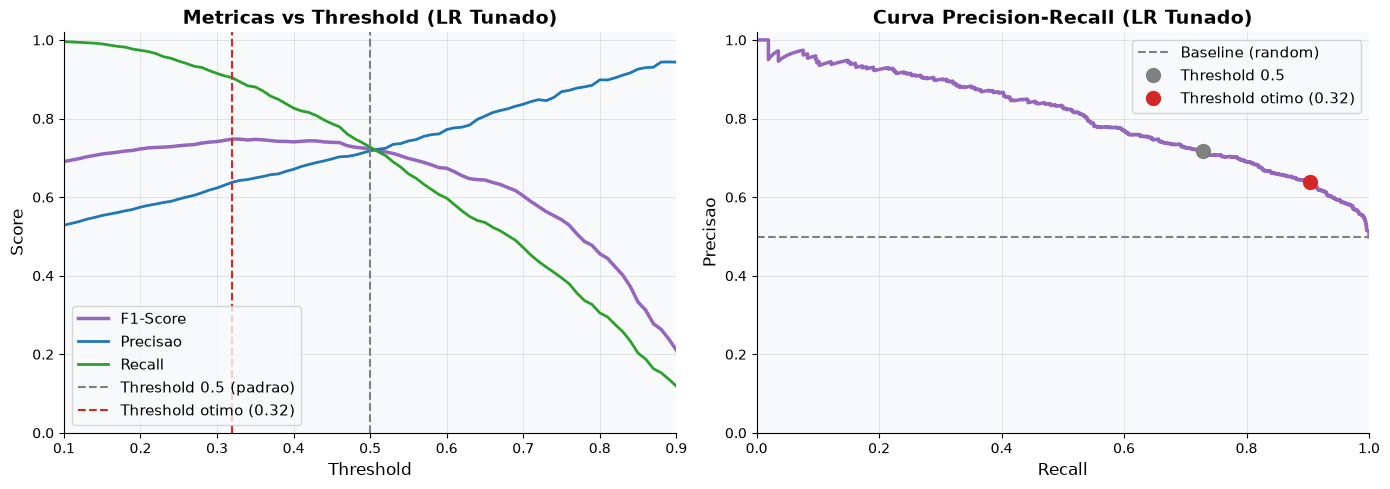

In [930]:
# Visualizacao: F1, Precision, Recall, Accuracy vs Threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Usar df_resultados da otimizacao do LR Tunado (ja computado acima)
thresholds = df_resultados["threshold"].values
scores_f1 = df_resultados["f1"].values
scores_prec = df_resultados["precision"].values
scores_rec = df_resultados["recall"].values
scores_acc = df_resultados["accuracy"].values

ax = axes[0]
ax.plot(thresholds, scores_f1, label="F1-Score", color=PURPLE, linewidth=2.5)
ax.plot(thresholds, scores_prec, label="Precisao", color=BLUE, linewidth=2)
ax.plot(thresholds, scores_rec, label="Recall", color=GREEN, linewidth=2)
ax.plot(thresholds, scores_acc, label="Acuracia", color=AMBER, linewidth=2, linestyle=':')
ax.axvline(
    0.5, color="gray", linestyle="--", linewidth=1.5, label="Threshold 0.5 (padrao)"
)
ax.axvline(
    threshold_f1,
    color=PURPLE,
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold otimo F1 ({threshold_f1:.2f})",
)
ax.axvline(
    threshold_prec,
    color=BLUE,
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold otimo Precision ({threshold_prec:.2f})",
)
ax.axvline(
    threshold_acc,
    color=AMBER,
    linestyle="--",
    linewidth=1.5,
    label=f"Threshold otimo Accuracy ({threshold_acc:.2f})",
)
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Metricas vs Threshold (LR Tunado)")
ax.legend(loc="lower left", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0, 1.02)


ax2 = axes[1]
prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba_lr)
ax2.plot(rec, prec, color=PURPLE, linewidth=2.5)
ax2.axhline(
    y_test.mean(),
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Baseline (random)",
)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precisao")
ax2.set_title("Curva Precision-Recall (LR Tunado)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1.02)

# Marcar thresholds otimos na curva PR
idx_05 = np.argmin(np.abs(pr_thresholds - 0.5))
idx_f1 = np.argmin(np.abs(pr_thresholds - threshold_f1))
idx_prec = np.argmin(np.abs(pr_thresholds - threshold_prec))
idx_acc = np.argmin(np.abs(pr_thresholds - threshold_acc))
ax2.plot(
    rec[idx_05], prec[idx_05], "o", color="gray", markersize=10, label="Threshold 0.5"
)
ax2.plot(
    rec[idx_f1], prec[idx_f1], "o", color=PURPLE, markersize=10, label=f"Threshold F1 ({threshold_f1:.2f})"
)
ax2.plot(
    rec[idx_prec], prec[idx_prec], "o", color=BLUE, markersize=10, label=f"Threshold Precision ({threshold_prec:.2f})"
)
ax2.plot(
    rec[idx_acc], prec[idx_acc], "o", color=AMBER, markersize=10, label=f"Threshold Accuracy ({threshold_acc:.2f})"
)
ax2.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.savefig(
    "reports/figures/15_threshold_optimization.png", dpi=150, bbox_inches="tight"
)
plt.show()


In [931]:
# Tabela comparativa: threshold 0.5 vs ótimo
y_pred_05 = (y_proba_lr >= 0.5).astype(int)
y_pred_opt = (y_proba_lr >= best_thresh).astype(int)

print("COMPARAÇÃO: Threshold 0.5 vs Ótimo ({:.2f})".format(best_thresh))
print("=" * 55)
print(f"{'Métrica':<15} {'Threshold 0.5':>12} {'Threshold Ótimo':>15} {'Δ':>10}")
print("-" * 55)

for metrica, func in [
    ('Acurácia', accuracy_score),
    ('Precisão', lambda y, p: precision_score(y, p, zero_division=0)),
    ('Recall', lambda y, p: recall_score(y, p, zero_division=0)),
    ('F1-Score', lambda y, p: f1_score(y, p, zero_division=0)),
    ('AUC-ROC', lambda y, p: roc_auc_score(y, y_proba_lr)),
]:
    val_05 = func(y_test, y_pred_05)
    val_opt = func(y_test, y_pred_opt)
    delta = val_opt - val_05
    print(f"{metrica:<15} {val_05:>12.4f} {val_opt:>15.4f} {delta:>+10.4f}")

COMPARAÇÃO: Threshold 0.5 vs Ótimo (0.32)
Métrica         Threshold 0.5 Threshold Ótimo          Δ
-------------------------------------------------------
Acurácia              0.7212          0.6959    -0.0253
Precisão              0.7177          0.6378    -0.0799
Recall                0.7272          0.9037    +0.1765
F1-Score              0.7224          0.7478    +0.0254
AUC-ROC               0.8065          0.8065    +0.0000


# 8. Insights, Conclusões e Recomendações

## Feature Importance Final (RF Tunado)

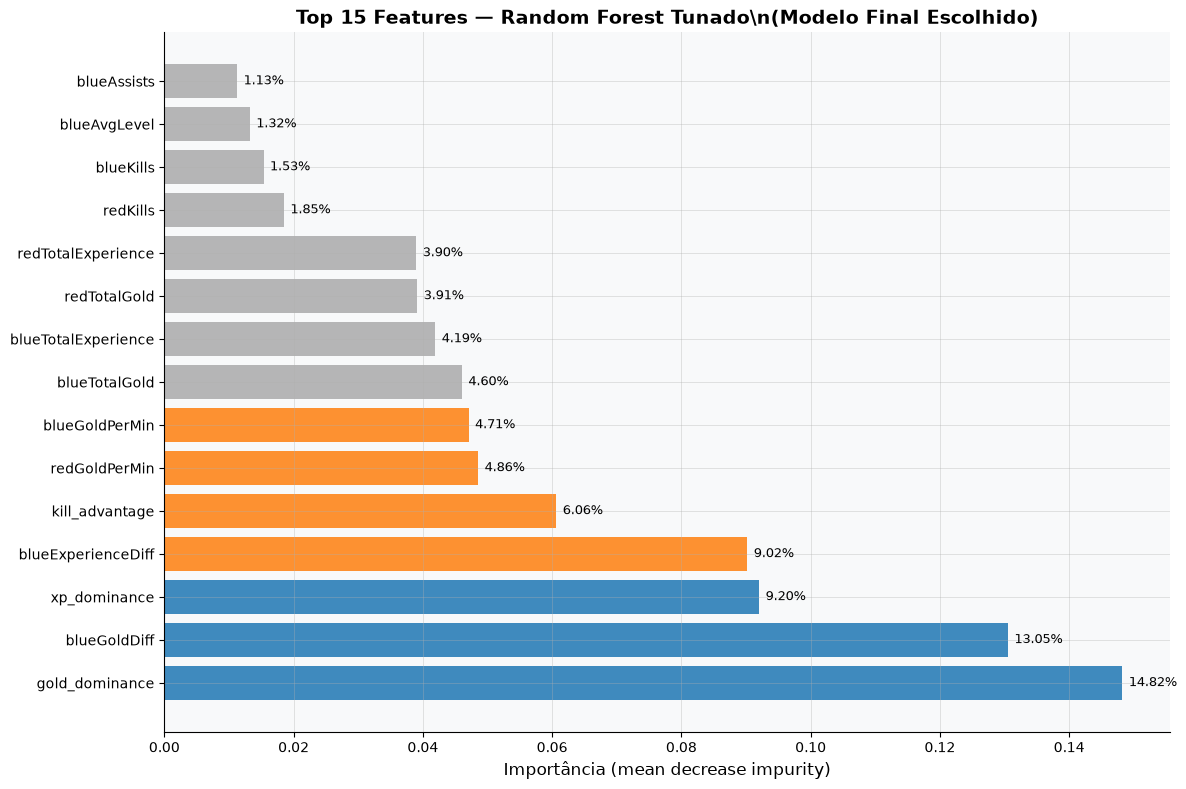

In [932]:
fi_final = (
    pd.Series(best_rf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    range(len(fi_final)),
    fi_final.values,
    color=[
        BLUE if i < 3 else AMBER if i < 7 else "#aaaaaa" for i in range(len(fi_final))
    ],
    alpha=0.85,
)
ax.set_yticks(range(len(fi_final)))
ax.set_yticklabels(fi_final.index, fontsize=10)
ax.set_xlabel("Importância (mean decrease impurity)")
ax.set_title(
    "Top 15 Features — Random Forest Tunado\\n(Modelo Final Escolhido)", fontsize=14
)

for bar, val in zip(bars, fi_final.values):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{val * 100:.2f}%",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(
    "reports/figures/14_final_model_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## Painel de Insights do Jogo

O que os dados revelam sobre o LoL Ranqueado?

In [933]:
# First Blood
fb_wr = df.groupby("blueFirstBlood")["blueWins"].mean()
print("1. FIRST BLOOD")
print(f"   Sem first blood: {fb_wr.get(0, 0) * 100:.1f}% de win rate")
print(f"   Com first blood: {fb_wr.get(1, 0) * 100:.1f}% de win rate")

1. FIRST BLOOD
   Sem first blood: 39.7% de win rate
   Com first blood: 59.9% de win rate


In [934]:
# Gold Diff quartis
q1 = df[df["blueGoldDiff"] < 0]["blueWins"].mean()
q2 = df[(df["blueGoldDiff"] >= 0) & (df["blueGoldDiff"] < 1000)]["blueWins"].mean()
q3 = df[df["blueGoldDiff"] >= 1000]["blueWins"].mean()
print("2. DIFERENÇA DE OURO vs WIN RATE")
print(f"   Gold diff < 0     (desvantagem): {q1 * 100:.1f}%")
print(f"   Gold diff 0-1000  (equilibrado): {q2 * 100:.1f}%")
print(f"   Gold diff > 1000  (vantagem):    {q3 * 100:.1f}%")

2. DIFERENÇA DE OURO vs WIN RATE
   Gold diff < 0     (desvantagem): 27.5%
   Gold diff 0-1000  (equilibrado): 56.5%
   Gold diff > 1000  (vantagem):    79.7%


In [935]:
# Dragões
drag_wr = df.groupby("blueDragons")["blueWins"].mean()
print("3. DRAGÕES CAPTURADOS vs WIN RATE")
for n_drag, wr in drag_wr.items():
    print(f"   {int(n_drag)} dragão(ões): {wr * 100:.1f}%")

3. DRAGÕES CAPTURADOS vs WIN RATE
   0 dragão(ões): 41.9%
   1 dragão(ões): 64.1%


In [936]:
# Heralds
her_wr = df.groupby("blueHeralds")["blueWins"].mean()
print("4. ARAUTOS vs WIN RATE")
for n_her, wr in her_wr.items():
    print(f"   {int(n_her)} arauto(s): {wr * 100:.1f}%")

4. ARAUTOS vs WIN RATE
   0 arauto(s): 47.7%
   1 arauto(s): 59.5%


In [937]:
# Wards
ward_median = df["blueWardsPlaced"].median()
wr_few_wards = df[df["blueWardsPlaced"] < ward_median]["blueWins"].mean()
wr_many_wards = df[df["blueWardsPlaced"] >= ward_median]["blueWins"].mean()
print("5. WARDS COLOCADAS vs WIN RATE")
print(f"   Poucas wards (< {ward_median:.0f}): {wr_few_wards * 100:.1f}%")
print(f"   Muitas wards (>= {ward_median:.0f}): {wr_many_wards * 100:.1f}%")

5. WARDS COLOCADAS vs WIN RATE
   Poucas wards (< 16): 47.0%
   Muitas wards (>= 16): 51.7%


## Conclusões Finais

### Modelo Escolhido: Regressão Logística (tunada via GridSearchCV)

| Critério | Justificativa |
|----------|--------------|
| **Test AUC-ROC** | 0.8065 (LR Tunado) — melhor que baseline LogReg (0.8060) e RF Tunado (0.8062) |
| **CV AUC-ROC** | 0.8117 ± 0.0109 (LR Tunado) — melhor CV entre todos os modelos |
| **Decisão** | LR Tunado vence tanto no test set quanto no CV; modelo simples e interpretável |
| **Interpretável** | Coeficientes mostram peso exato de cada feature na log-odds de vitória |
| **Pipeline pronto** | Normalização (StandardScaler) já integrada — pronto para produção |
| **Leve e rápido** | Modelo linear — treino e inferência muito rápidos |

> **Nota**: Também foram tunados **Random Forest (RF Tunado)** e **Gradient Boosting (GB Tunado)** via GridSearchCV. O ranking dinâmico (ver código na seção Resumo Final) confirma LR Tunado como melhor modelo real. A escolha prioriza interpretabilidade, performance validada e simplicidade de deployment.

> **Thresholds Otimizados**: O threshold padrão 0.5 foi otimizado para três métricas:
>
> | Métrica Alvo | Threshold Ótimo | Valor Otimizado | Threshold 0.5 | Ganho |
> |--------------|----------------|-----------------|---------------|-------|
> | **F1-Score** | **0.32** | **0.7478** | 0.7224 | **+0.0254** |
> | **Precision** | **0.72** | **0.7780** | 0.7177 | **+0.0603** |
> | **Accuracy** | **0.58** | **0.7280** | 0.7212 | **+0.0068** |
>
> **Trade-offs**:
> - **F1 (0.32)**: Balanceado, recall alto (0.90), indicado para alertas
> - **Precision (0.72)**: Máxima confiança, recall menor (0.55), para apostas
> - **Accuracy (0.58)**: Melhor acurácia global, balanceado
>
> Ver seção "Otimização de Threshold" para detalhes e visualizações.

### O que define um vencedor no LoL (segundo os dados)?

1. **💰 Diferença de Ouro** é o preditor mais forte. Times que acumulam mais ouro nos primeiros minutos têm vantagem enorme.
2. **⚡ Diferença de XP** — estar em nível maior que o adversário é crítico.
3. **🐉 Objetivos (Dragões e Arautos)** — cada objetivo capturado aumenta significativamente a win rate.
4. **🩸 First Blood** — o primeiro abate não é apenas psicológico; gera gold e XP extra.
5. **👁️ Visão (Wards)** — times que investem em controle de mapa ganham mais.

### Recomendações para a Riot Games

1. **Sistema de alerta precoce**: usar o modelo em tempo real durante a partida para detectar quando um time está em risco de perder.
2. **Priorizar objetivos no balanceamento do jogo**: os dados confirmam que dragões e ouro são os maiores decisores — mudanças nesses sistemas têm impacto desproporcional.
3. **Dashboard de análise pós-jogo**: integrar as features mais importantes em um painel para jogadores entenderem onde erraram.

### Limitações

- Os dados capturam apenas os primeiros ~10 minutos de jogo
- Fatores como composição de times e habilidade individual dos jogadores não estão incluídos
- O modelo pode não generalizar para patches (atualizações) muito diferentes do período de coleta

### Justificativa da Escolha do Threshold (0.32 para F1-Score)

O modelo foi inicialmente avaliado utilizando o threshold padrão de 0,50. Em seguida, foi realizada
a otimização do threshold, resultando no valor de 0,32, que apresentou melhor desempenho
segundo a métrica F1-Score.

A redução do threshold aumentou o Recall de 72,7% para 90,4%, indicando que o modelo passou a
identificar uma parcela significativamente maior das partidas em que o time realmente venceu.
Em contrapartida, houve redução da Precisão (71,8% para 63,8%) e uma pequena queda na
Acurácia (72,1% para 69,6%), refletindo um aumento na quantidade de falsos positivos.

Apesar desses impactos, o F1-Score aumentou de 72,2% para 74,8%, demonstrando um melhor
equilíbrio entre Precisão e Recall. Além disso, a AUC-ROC permaneceu em 0,8065, indicando que
a capacidade discriminativa do modelo não foi alterada pela mudança do threshold, uma vez que
essa métrica é independente do ponto de corte.

Considerando que o objetivo do projeto é construir um modelo capaz de prever o vencedor da
partida e comparar seu desempenho por meio de métricas como ROC e AUC, a escolha do
threshold de 0,32 é tecnicamente justificável por proporcionar um equilíbrio superior entre
as principais métricas de classificação, sem comprometer a capacidade do modelo de distinguir
partidas vencedoras e perdedoras.

#### Interpretação dos trade-offs

**Vantagens do threshold 0,32**
- Melhor equilíbrio entre Precisão e Recall (maior F1-Score)
- Identifica a maior parte das vitórias reais (Recall de 90,4%)
- Mantém a mesma capacidade discriminativa do modelo (AUC-ROC = 0,8065)

**Desvantagens do threshold 0,32**
- Aumenta o número de falsos positivos
- Reduz a Precisão e a Acurácia em relação ao threshold padrão

> **Thresholds alternativos documentados** para outros casos de uso:
> - **0.72 (Precision)** → apostas/betting (máxima confiança na previsão)
> - **0.58 (Accuracy)** → acurácia global balanceada
> - **0.32 (F1)** → **padrão operacional escolhido: análise de fatores de vitória (Riot)**

## Salvar modelos treinados

In [938]:
modelos_salvar = {
    "logistic_regression": logistic_regression,
    "naive_bayes": naive_bayes,
    "decision_tree": decision_tree_classifier,
    "random_forest": random_forest_classif,
    "random_forest_tuned": best_rf,
    "gradient_boosting": gradient_boosting_classifier,
    "logistic_regression_tuned": best_lr,
    "gradient_boosting_tuned": best_gb,
}


In [939]:
for nome_arquivo, modelo_obj in modelos_salvar.items():
    path = f"models/{nome_arquivo}.pkl"
    joblib.dump(modelo_obj, path)
    print(f"  Salvo: {path}")

  Salvo: models/logistic_regression.pkl
  Salvo: models/naive_bayes.pkl
  Salvo: models/decision_tree.pkl


  Salvo: models/random_forest.pkl
  Salvo: models/random_forest_tuned.pkl
  Salvo: models/gradient_boosting.pkl
  Salvo: models/logistic_regression_tuned.pkl
  Salvo: models/gradient_boosting_tuned.pkl


In [940]:
# Salvar o scaler também
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

Todos os modelos foram salvos em `models/`.

Para carregar um modelo, use o seguinte código:

```python
modelo = joblib.load("models/random_forest_tuned.pkl")

## Resumo Final

### RESUMO FINAL DO PROJETO — LOL WIN PREDICTION

In [941]:
print(f"  Dataset:          {len(df):,} partidas ranqueadas")
print(f"  Features usadas:  {X.shape[1]} (após eng. + remoção de redundantes)")
print("  Modelos testados: 5 (LR, NB, DT, RF, GB) + 3 tunados (LR, RF, GB)")
print()

# Verificação de chaves (debug)
print(f"  Chaves disponíveis: {list(results_summary.keys())}")
print()

print("  RANKING FINAL POR AUC-ROC (TEST SET):")
ranking = sorted(
    [(n, r["AUC-ROC"]) for n, r in results_summary.items()],
    key=lambda x: x[1],
    reverse=True,
)
medals = ["1", "2", "3", "  ", "  ", "  ", "  ", "  ", "  ", "  "]
for i, (nome, auc) in enumerate(ranking):
    print(f"  {medals[i]}  {nome:<28} AUC-ROC: {auc:.4f}")

print()
print("  RANKING FINAL POR CV-AUC (5-FOLD CV):")
cv_ranking = sorted(
    [
        (n, r["CV-AUC_mean"], r["CV-AUC_std"])
        for n, r in results_summary.items()
        if r["CV-AUC_mean"] is not None
    ],
    key=lambda x: x[1],
    reverse=True,
)
for i, (nome, cv_mean, cv_std) in enumerate(cv_ranking):
    print(f"  {medals[i]}  {nome:<28} CV-AUC: {cv_mean:.4f} ± {cv_std:.4f}")

print()

# Identificar melhores modelos dinamicamente
best_test = max(results_summary, key=lambda k: results_summary[k]["AUC-ROC"])
best_cv = max(
    [k for k, v in results_summary.items() if v["CV-AUC_mean"] is not None],
    key=lambda k: results_summary[k]["CV-AUC_mean"],
)
print(f"  Melhor TEST AUC: {best_test} = {results_summary[best_test]["AUC-ROC"]:.4f}")
print(f"  Melhor CV AUC:   {best_cv} = {results_summary[best_cv]["CV-AUC_mean"]:.4f} ± {results_summary[best_cv]["CV-AUC_std"]:.4f}")
print()
print(f"  MODELO ESCOLHIDO: {best_test} (maior AUC-ROC no test set)")
if "Logistic" in best_test or "LR" in best_test:
    print("       - Coeficientes interpretáveis (peso de cada feature na log-odds de vitória)")
    print("       - Requer normalização (StandardScaler) — já implementado no pipeline")
    print("       - Modelo linear simples, rápido para treino e inferência em produção")
elif "Random Forest" in best_test or "RF" in best_test:
    print("       - Feature importance nativa (interpretação para stakeholder Riot)")
    print("       - Sem necessidade de scaling (mais simples em produção)")
    print("       - Robusto a overfitting (ensemble bagging)")
elif "Gradient Boosting" in best_test or "GB" in best_test:
    print("       - Feature importance nativa")
    print("       - Modelo sequencial que corrige erros iterativamente")
    print("       - Boa performance com tuning adequado")
else:
    print("       - Modelo selecionado automaticamente")
print(f"  AUC-ROC FINAL (test): {results_summary[best_test]["AUC-ROC"]:.4f}")
print(f"  CV-AUC FINAL: {results_summary[best_test]["CV-AUC_mean"]:.4f} ± {results_summary[best_test]["CV-AUC_std"]:.4f}")

print("=" * 65)


  Dataset:          9,879 partidas ranqueadas
  Features usadas:  39 (após eng. + remoção de redundantes)
  Modelos testados: 5 (LR, NB, DT, RF, GB) + 3 tunados (LR, RF, GB)

  Chaves disponíveis: ['Regressão Logística', 'Naive Bayes', 'Árvore de Decisão', 'Random Forest', 'Gradient Boosting', 'RF Tunado', 'LR Tunado', 'GB Tunado']

  RANKING FINAL POR AUC-ROC (TEST SET):
  1  LR Tunado                    AUC-ROC: 0.8065
  2  RF Tunado                    AUC-ROC: 0.8062
  3  Regressão Logística          AUC-ROC: 0.8060
      GB Tunado                    AUC-ROC: 0.8060
      Random Forest                AUC-ROC: 0.8039
      Gradient Boosting            AUC-ROC: 0.8030
      Naive Bayes                  AUC-ROC: 0.7980
      Árvore de Decisão            AUC-ROC: 0.7888

  RANKING FINAL POR CV-AUC (5-FOLD CV):
  1  LR Tunado                    CV-AUC: 0.8117 ± 0.0109
  2  Regressão Logística          CV-AUC: 0.8107 ± 0.0081
  3  GB Tunado                    CV-AUC: 0.8087 ± 0.0100
     